# Import Data

In [1]:
# ---------------------------------------------------------
# 01) Libraries, Files, Constants
# ---------------------------------------------------------

from pathlib import Path
import pandas as pd
from Bio import SeqIO
from Bio import AlignIO
from Bio.PDB import PDBParser

PROJECT_ROOT = Path.cwd()
FASTA_FILE = PROJECT_ROOT / "fasta" / "atropinesterases.fasta"
ALIGNMENT_FILE = PROJECT_ROOT / "fasta" / "atropinesterases_alignment.a3m"
PDB_ALIGNMENT = PROJECT_ROOT / "fasta" / "pdb_alignment.a3m"
PDB_DIR = PROJECT_ROOT / "pdb"
RESULTS_DIR = PROJECT_ROOT / "results"
SCENARIO = "06_strict_surface"

WT_CATALYTIC_TRIAD = [111, 229, 257] # Ser111 (nucleophile), Asp229 (acid) and His257 (base)
TARGET_NTERM_TRUNCATION = 2 # For better alignment and folding, I have deleted the first two residues in the target

def wt_to_target_residue_idx(wt_res_idx): # Convert WT (full-length) residue index to target residue index.
    target_idx = wt_res_idx - TARGET_NTERM_TRUNCATION
    return target_idx if target_idx > 0 else None

def target_to_wt_residue_idx(target_res_idx):
    return target_res_idx + TARGET_NTERM_TRUNCATION #  Convert target residue index to WT (full-length) residue index.

pd.set_option("display.max_colwidth", None)
# -------------------------------------------------
# Distance cutoff (Å) for exposure proxy used in cell 11
# -------------------------------------------------
# Used to determine if a residue is on the surface of the protein.
# Surface proteins have less neighboring residues.
# Look within a a
NEIGHBOR_CUTOFF = 10.0 # (Å) Other residues within this distance are considered neighbors
MIN_NEIGHBORS_BURIED = 16 # Number of neighbor needed for the residue to be buried (non-surface)

# -------------------------------------------------
# Sequence weights (GLOBAL HYPERPARAMETER) used in cell 14
# -------------------------------------------------
# Controls relative contribution of target vs references.
# Examples:
#   Target-only:      {"A0A515BEI4": 1.0, "A0A2D9RK65": 0.0, "A0A4R9PVA8": 0.0}
#   Equal weighting:  {"A0A515BEI4": 1.0, "A0A2D9RK65": 1.0, "A0A4R9PVA8": 1.0}
#   Target-biased:    {"A0A515BEI4": 1.0, "A0A2D9RK65": 0.5, "A0A4R9PVA8": 0.5}
SEQ_WEIGHTS = {
    "A0A515BEI4": 1.0,   # target
    "A0A2D9RK65": 1.0,   # reference 1
    "A0A4R9PVA8": 1.0,   # reference 2
}

# -------------------------------------------------
# Weights (GLOBAL HYPERPARAMETER) used in cell 19
# -------------------------------------------------
# Used for ranking proposed single point mutations, balance composite score between 
# ESM delta logP score and Mutation Priority score derived from sequence and structure analysis
W_ESM    = 0.6
W_STRUCT = 0.4

In [2]:
# ---------------------------------------------------------
# 02) Load FASTA sequences (in order)
# ---------------------------------------------------------

records = list(SeqIO.parse(FASTA_FILE, "fasta"))

# Assign roles by order
target_seq = records[0]
ref_seqs   = records[1:]

# Store sequences + metadata in a table
rows = []

for i, rec in enumerate(records):
    if i == 0:
        role = "target"
    else:
        role = "reference"

    rows.append({
        "seq_id": rec.id,
        "role": role,
        "length": len(rec.seq),
        "sequence": str(rec.seq)
    })

seq_df = pd.DataFrame(rows)

seq_df

,seq_id,role,length,sequence
0,UPI00115BD180_A0A515BEI4(Met1-Gln2del),target,278,QKITPPSQEDWVNSKKYLKINDQVEMAYVEWGNPSGEPIFLIHGYSDSSRAYSTVAPLLQGARFIAPDLRGHGNTTAPNGAYGIQCLAEDISDFIDALGYKRAKVVGHSMGSLTAGLLASFYPEKVEKLILISSAVKMNPDVSKWLYEQIVTFAYPTDPNNGWLEREWAGNPNGIFDDVMMKLLRKEQAAMPQRVWASLLKAMDTLDWSHAARHITAPTLIMWGDQDTLMTEAEQGPLCQAIPHAIFKRYEGKGHSMYWEDPQEGANDIMDFLMASNL
1,sp|P07383|TPES_PSEPU,reference,272,EIIPVPDQAAWNASKKSIQINDAIKMRYVEWGNPSGDPVLLLHGYTDTSRAFSSLAPFLSKDKRYLALDLRGHGGTSIPKCCYYVSDFAEDVSDFIDKMGLHNTTVIGHSMGSMTAGVLASIHPDKVSRLVLISTALKTGPVLEWVYDTVLQKDFPLDDPSEFAKEWVAAPGKHDNGMAKNLKTEELAVPKHVWLSAARGFSIINWTAASKYLTAKTLILWGNQNQPMTESMQNDIRAALPKAKFIQYNGFGHSMFWEDPEMVAKDLNEFLK
2,UPI000C96F8C2_A0A2D9RK65(Met1-Ser18del),reference,274,EAQTIDPPSQTDWVASKQYIQINSDVRMAYVEWGDPEGEPVLLIHGYSDNSRVWGTIAPYLKDRHYFAIDMRGHGDTSIPECCFYLSDFAEDASDFIHAQGFDSMDVVGHSLGSGTAGVLASMHPEEVSKLVLVSSAPFFGNGVSWLNDALAEAQFPLDPEGTFIQTWAYNPGNMDETMLGPLRYEEAAMPERVWKSIARGLEIVNWGPAAARITAPALILWGDQDELILEADQVALRAALPDAKFIRYDGLGHSMYWEDPARVASDLLRFLDE
3,UPI000FCCAD69_A0A4R9PVA8(Met1-Ile10del),reference,270,IAPPSQEEWVAAKKCVRINEQIQLAYVEWGNTEAEPAILVHGYSDNSRAYSTIAPHLSDKHYHAVDLRGHGNSSKPESRYHASDFAEDIGDFIKAMGYQKACVVGHSLGSITAGVLASVHPECVSRLVLISSTLRTGPFVDWVEAELSKARFPLDVNGEFIKAWAANPGGMDEAMLAPLRHEEAAMPECAWRGIARGLQTLDWTQAARHITAPTLIMWGDKDELMLESDQEALRRALPSAKFVRYDGLGHSMYWEEPERISRDLTAFLAQ
4,WP_020336068.1(Met1-Ile11del),reference,285,LLQSIAVCSYAKTILPPSQDDWVSSKQYVQVNDQVKMAYVEWGNPDAEPVVLVHGYSDNSRAYSTIAPYLNDKHYFAVDLRGHGNTSAPTCCYYIGNYAEDVSDFINVMKLKSPALVGHSLGSITAGTLASIHPKQISKLVLISSAVKMNPDVSKWLYDTVTTLNYPLDPKGDFIQKEWAPNPGDMDEKMLSKLRQEEAAMPQNAWVGTIKGLEIMDWSLAARHISVPTLIMWGDQDELMQEKQNNDLQKAIPDAKMIVYKGLGHSMYWQQPERCAKDLMSFING
5,WP_1384642764.1(Met1-Ala21del),reference,271,DSIAPPDQASWNGAKQMADLGNGIELAYVEWGDPEADPVILVHGFSDSSRAFSTIAPFLDGHRFIAVDLRGMGDSSEPECCYYPTDFAEDLNAFIHALGYDKAAVVGHSVGSIYAGMLAALHPASVERLVLISSRLDQSGRRGFLDMVEGLDFPLDPMGEFIQDWGGNNGRMDEEMLTYLRIEEAGMPKRAWAGMAKGMELVDWTLAAERIAAPTLILWGDQDGMAKAQDQEDLQAAMPAATFIAYEGYGHSMYWENPEMVATDLTAFLDD


# Functional Constraints: Catalytic Triad & Locked Positions



In [3]:
# ---------------------------------------------------------
# 03) Alignment Mapping (canonical, downstream-safe)
# ---------------------------------------------------------

import math
from collections import Counter

alignment = AlignIO.read(ALIGNMENT_FILE, "fasta")

# ---------------------------------------------------------
# Locate target sequence in alignment
# ---------------------------------------------------------
target_aln = None
for record in alignment:
    if record.id == target_seq.id:
        target_aln = str(record.seq)
        break

if target_aln is None:
    raise ValueError(
        f"Target sequence '{target_seq.id}' not found in alignment"
    )

# ---------------------------------------------------------
# Build alignment-column → target-residue-index map (1-based)
# ---------------------------------------------------------
target_pos_map = []
pos = 0
for aa in target_aln:
    if aa != "-":
        pos += 1
        target_pos_map.append(pos)
    else:
        target_pos_map.append(None)

L = alignment.get_alignment_length()
rows = []

# ---------------------------------------------------------
# Column-wise conservation statistics
# ---------------------------------------------------------
for col in range(L):
    col_aas = [
        rec.seq[col]
        for rec in alignment
        if rec.seq[col] != "-"
    ]

    counts = Counter(col_aas)
    total = sum(counts.values())

    if total > 0:
        freqs = {aa: c / total for aa, c in counts.items()}
        entropy = -sum(p * math.log2(p) for p in freqs.values())
        top_aa, top_count = counts.most_common(1)[0]
        top_freq = top_count / total
    else:
        freqs = {}
        entropy = float("nan")
        top_aa = None
        top_freq = None

    rows.append({
        "aln_col": col + 1,
        "target_idx": target_pos_map[col],
        "target_aa": target_aln[col],
        "non_gap_n": total,
        "entropy": entropy,
        "top_aa": top_aa,
        "top_freq": top_freq,
        "freqs": freqs,   # kept for inspection/debugging
    })

cons_df = pd.DataFrame(rows)

cons_df.head(10)

,aln_col,target_idx,target_aa,non_gap_n,entropy,top_aa,top_freq,freqs
0,1,1.0,Q,5,1.921928,Q,0.400000,"{'Q': 0.4, 'E': 0.2, 'K': 0.2, 'D': 0.2}"
1,2,2.0,K,5,1.921928,T,0.400000,"{'K': 0.2, 'I': 0.2, 'T': 0.4, 'S': 0.2}"
2,3,3.0,I,6,-0.000000,I,1.000000,{'I': 1.0}
3,4,4.0,T,6,2.251629,A,0.333333,"{'T': 0.16666666666666666, 'P': 0.16666666666666666, 'D': 0.16666666666666666, 'A': 0.3333333333333333, 'L': 0.16666666666666666}"
4,5,5.0,P,6,0.650022,P,0.833333,"{'P': 0.8333333333333334, 'V': 0.16666666666666666}"
5,6,6.0,P,6,-0.000000,P,1.000000,{'P': 1.0}
6,7,7.0,S,6,0.918296,S,0.666667,"{'S': 0.6666666666666666, 'D': 0.3333333333333333}"
7,8,8.0,Q,6,-0.000000,Q,1.000000,{'Q': 1.0}
8,9,9.0,E,6,1.918296,E,0.333333,"{'E': 0.3333333333333333, 'A': 0.3333333333333333, 'T': 0.16666666666666666, 'D': 0.16666666666666666}"
9,10,10.0,D,6,1.792481,D,0.500000,"{'D': 0.5, 'A': 0.16666666666666666, 'E': 0.16666666666666666, 'S': 0.16666666666666666}"


In [4]:
# ---------------------------------------------------------
# 04) Build mutation mask (conservation + catalytic locks)
# ---------------------------------------------------------

# -------------------------------
# Conservation-based LOCK criteria
# -------------------------------
MIN_COVERAGE     = 3    # minimum number of non-gap residues
ENTROPY_CUTOFF   = 0.3
TOP_FREQ_CUTOFF  = 0.9

# -------------------------------
# Catalytic triad (TARGET indices, 1-based)
# -------------------------------
TARGET_CATALYTIC_TRIAD = [
    wt_res - TARGET_NTERM_TRUNCATION
    for wt_res in WT_CATALYTIC_TRIAD
]


def conservation_lock(row):
    '''
    Determine whether an alignment position should be LOCKed
    based on conservation criteria.
    '''
    conserved = (
        row["non_gap_n"] >= MIN_COVERAGE and
        (row["entropy"] < ENTROPY_CUTOFF or row["top_freq"] >= TOP_FREQ_CUTOFF)
    )

    if conserved:
        return "LOCK", "conserved"
    else:
        return "MUTABLE", "variable"

# ---------------------------------------------------------
# Build mutation mask (conservation + catalytic locks)
# ---------------------------------------------------------

def build_mutation_mask(
    cons_df,
):
    '''
    Build mutation mask dataframe combining conservation-based
    and catalytic locks.
    '''
    mask_rows = []

    for _, row in cons_df.iterrows():
        target_idx = row["target_idx"]

        # Skip positions not present in target
        if pd.isna(target_idx):
            continue

        status, reason = conservation_lock(
            row,
        )

        mask_rows.append({
            "target_idx": int(target_idx),
            "target_aa": row["target_aa"],
            "status": status,
            "lock_reason": reason,
            "entropy": row["entropy"],
            "top_aa": row["top_aa"],
            "top_freq": row["top_freq"],
            "non_gap_n": row["non_gap_n"],
        })

    mask_df = pd.DataFrame(mask_rows)

    # -------------------------------
    # Apply catalytic triad LOCK
    # -------------------------------
    mask_df.loc[
        mask_df["target_idx"].isin(TARGET_CATALYTIC_TRIAD),
        ["status", "lock_reason"]
    ] = ["LOCK", "catalytic"]

    return mask_df

mask_df = build_mutation_mask(cons_df)
mask_df.head(10)

# -------------------------------
# Export locked residues
# -------------------------------
locked_df = (
    mask_df
    .loc[mask_df["status"] == "LOCK"]
    .sort_values("target_idx")
)

out_path = RESULTS_DIR / SCENARIO / "locked_residues.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
locked_df.to_csv(out_path, index=False)

print(f"Wrote {len(locked_df)} locked residues to {out_path}")

Wrote 74 locked residues to /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/locked_residues.csv


# Baseline evaluation of the target

In [5]:

# ---------------------------------------------------------
# 05) Build charge table
# ---------------------------------------------------------

from Bio import SeqIO
from Bio.SeqUtils import IsoelectricPoint as IP
from Bio.SeqUtils import ProtParam
import pandas as pd

PH_VALUES = [6.8, 7.4, 8.0]

records = list(SeqIO.parse(FASTA_FILE, "fasta"))

def compute_charge_properties(seq):
    '''
    Compute pI and net charge at given pH values
    for a protein sequence (assumed clean).
    '''
    seq_str = str(seq)

    ip_calc = IP.IsoelectricPoint(seq_str)

    props = {
        "length": len(seq_str),
        "pI": round(ip_calc.pi(), 2),
    }

    for ph in PH_VALUES:
        props[f"charge_pH_{ph}"] = round(ip_calc.charge_at_pH(ph), 2)

    return props


def build_charge_table(records):
    '''
    Build a table of pI and charge properties from FASTA records.
    '''
    rows = []

    for i, rec in enumerate(records):
        props = compute_charge_properties(rec.seq)

        rows.append({
            "seq_id": rec.id,
            "role": "target" if i == 0 else "reference",
            **props,
        })

    return pd.DataFrame(rows)


charge_df = build_charge_table(records)
charge_df

,seq_id,role,length,pI,charge_pH_6.8,charge_pH_7.4,charge_pH_8.0
0,UPI00115BD180_A0A515BEI4(Met1-Gln2del),target,278,5.16,-9.17,-10.27,-11.13
1,sp|P07383|TPES_PSEPU,reference,272,6.26,-2.00,-3.14,-4.05
2,UPI000C96F8C2_A0A2D9RK65(Met1-Ser18del),reference,274,4.36,-25.08,-26.13,-26.92
3,UPI000FCCAD69_A0A4R9PVA8(Met1-Ile10del),reference,270,5.46,-9.63,-11.15,-12.19
4,WP_020336068.1(Met1-Ile11del),reference,285,5.48,-6.21,-7.35,-8.39
5,WP_1384642764.1(Met1-Ala21del),reference,271,4.22,-28.26,-29.27,-30.02


In [6]:
# -------------------------------
# 06) Sequence-level stickiness heuristics
# -------------------------------

import pandas as pd

# Amino-acid groups
HYDROPHOBIC_1 = set("AILMFWV")
AROMATIC_1    = set("FWY")

def longest_hydrophobic_stretch(seq, hydrophobic_set=HYDROPHOBIC_1):
    '''
    Length of the longest contiguous stretch of hydrophobic residues.
    '''
    max_len = 0
    current = 0

    for aa in seq:
        if aa in hydrophobic_set:
            current += 1
            max_len = max(max_len, current)
        else:
            current = 0

    return max_len

def compute_sequence_stickiness(seq):
    '''
    Compute sequence-level stickiness heuristics.
    '''
    length = len(seq)

    hydrophobic_count = sum(aa in HYDROPHOBIC_1 for aa in seq)
    aromatic_count    = sum(aa in AROMATIC_1 for aa in seq)

    return {
        "length": length,
        "hydrophobic_fraction": round(hydrophobic_count / length, 3),
        "aromatic_fraction": round(aromatic_count / length, 3),
        "longest_hydrophobic_stretch": longest_hydrophobic_stretch(seq),
    }
    
    import pandas as pd

def build_stickiness_table(records):
    '''
    Build sequence-level stickiness table from FASTA records.
    '''
    rows = []

    for i, rec in enumerate(records):
        metrics = compute_sequence_stickiness(str(rec.seq))

        rows.append({
            "seq_id": rec.id,
            "role": (
                "target" if i == 0 else
                "literature" if i == 1 else
                "reference"
            ),
            **metrics,
        })

    return pd.DataFrame(rows)

stickiness_df = build_stickiness_table(records)
stickiness_df

,seq_id,role,length,hydrophobic_fraction,aromatic_fraction,longest_hydrophobic_stretch
0,UPI00115BD180_A0A515BEI4(Met1-Gln2del),target,278,0.392,0.101,4
1,sp|P07383|TPES_PSEPU,literature,272,0.401,0.099,4
2,UPI000C96F8C2_A0A2D9RK65(Met1-Ser18del),reference,274,0.412,0.109,5
3,UPI000FCCAD69_A0A4R9PVA8(Met1-Ile10del),reference,270,0.400,0.085,4
4,WP_020336068.1(Met1-Ile11del),reference,285,0.375,0.091,4
5,WP_1384642764.1(Met1-Ala21del),reference,271,0.428,0.100,5


# Structural baseline

In [7]:
# -------------------------------------------------
# 07) STRUCTURE-AWARE ANALYSIS — INITIALIZATION
# -------------------------------------------------

from Bio.PDB import PDBParser
import pandas as pd

parser = PDBParser(QUIET=True)

def load_structures(pdb_dir):
    '''
    Load AlphaFold PDB structures into a unified DataFrame.
    '''
    rows = []

    # Target (custom AlphaFold)
    custom_pdb = pdb_dir / "A0A515BEI4_alphafold2_model_2_seed_000.pdb"
    structure = parser.get_structure(custom_pdb.stem, custom_pdb)

    rows.append({
        "seq_id": "A0A515BEI4",
        "pdb_file": custom_pdb.name,
        "structure_type": "alphafold_custom",
        "structure": structure
    })

    # Reference AlphaFold models
    for pdb_file in sorted(pdb_dir.glob("AF-*.pdb")):
        name = pdb_file.stem
        seq_id = name.split("-")[1]
        structure = parser.get_structure(name, pdb_file)

        rows.append({
            "seq_id": seq_id,
            "pdb_file": pdb_file.name,
            "structure_type": "alphafold_uniprot",
            "structure": structure
        })

    return pd.DataFrame(rows)

struct_df = load_structures(PDB_DIR)

struct_df[["seq_id", "pdb_file", "structure_type"]]

,seq_id,pdb_file,structure_type
0,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,alphafold_custom
1,A0A2D9RK65,AF-A0A2D9RK65-F1-model_v6.pdb,alphafold_uniprot
2,A0A4R9PVA8,AF-A0A4R9PVA8-F1-model_v6.pdb,alphafold_uniprot


In [8]:
# -------------------------------
# 08) Alignment → PDB residue mapping
# -------------------------------

from Bio import AlignIO

HIGHCONF_PLDDT_CUTOFF = 70.0

# -------------------------------------------------
# Shared helpers
# -------------------------------------------------

def get_chain(struct):
    '''Return the first chain from a structure.'''
    return list(struct.get_chains())[0]

def get_plddt(res):
    '''Return pLDDT from CA B-factor (AlphaFold convention).'''
    return res["CA"].get_bfactor()

# -------------------------------------------------
# Build alignment → PDB mapping
# -------------------------------------------------

def build_alignment_to_pdb_map(alignment, struct_df):
    '''
    Build mapping from alignment columns to PDB residues
    for each structure.
    '''
    # Map seq_id -> aligned sequence
    aln_seqs = {}

    for rec in alignment:
        for seq_id in struct_df["seq_id"]:
            if seq_id in rec.id:
                aln_seqs[seq_id] = str(rec.seq)

    # Sanity check
    missing = set(struct_df["seq_id"]) - set(aln_seqs.keys())
    if missing:
        raise KeyError(f"Missing alignment for seq_id(s): {missing}")

    aln_len = alignment.get_alignment_length()
    mapping = {}

    for _, row in struct_df.iterrows():
        seq_id = row["seq_id"]
        chain = get_chain(row["structure"])
        aln_seq = aln_seqs[seq_id]

        pdb_residues = [
            res for res in chain
            if res.id[0] == " " and "CA" in res
        ]

        pdb_idx = 0
        col_map = []

        for col in range(aln_len):
            if aln_seq[col] == "-":
                col_map.append(None)
            else:
                col_map.append(
                    pdb_residues[pdb_idx]
                    if pdb_idx < len(pdb_residues)
                    else None
                )
                pdb_idx += 1

        mapping[seq_id] = col_map

    return mapping

# -------------------------------------------------
# Build mapping ONCE (reused downstream)
# -------------------------------------------------

alignment = AlignIO.read(PDB_ALIGNMENT, "fasta")
alignment_to_pdb = build_alignment_to_pdb_map(alignment, struct_df)

# Optional sanity print
for seq_id, col_map in alignment_to_pdb.items():
    print(seq_id, "aligned residues:", sum(r is not None for r in col_map))

A0A515BEI4 aligned residues: 272
A0A2D9RK65 aligned residues: 292
A0A4R9PVA8 aligned residues: 280


In [9]:
# -------------------------------
# 09) Structure sanity & confidence (AlphaFold)
# -------------------------------

import pandas as pd
import numpy as np

def extract_plddt_from_chain(chain):
    '''
    Extract per-residue pLDDT values from a single protein chain.
    '''
    plddts = []

    for res in chain:
        if res.id[0] != " ":
            continue
        if "CA" in res:
            plddts.append(res["CA"].bfactor)

    return np.array(plddts)

def build_confidence_table(struct_df):
    '''
    Build structure-level sanity and confidence metrics for AlphaFold models.
    '''
    rows = []

    for _, row in struct_df.iterrows():
        structure = row["structure"]
        seq_id = row["seq_id"]
        pdb_file = row["pdb_file"]

        # Assume single-chain AlphaFold models
        chain = get_chain(structure)

        plddts = extract_plddt_from_chain(chain)

        rows.append({
            "seq_id": seq_id,
            "pdb_file": pdb_file,
            "n_residues": len(plddts),
            "mean_pLDDT": round(plddts.mean(), 1),
            "median_pLDDT": round(np.median(plddts), 1),
            "fraction_low_confidence_<70": round(
                (plddts < HIGHCONF_PLDDT_CUTOFF).mean(), 3
            ),
            "fraction_very_low_confidence_<50": round(
                (plddts < 50).mean(), 3
            ),
        })

    return pd.DataFrame(rows)

confidence_df = build_confidence_table(struct_df)
confidence_df

,seq_id,pdb_file,n_residues,mean_pLDDT,median_pLDDT,fraction_low_confidence_<70,fraction_very_low_confidence_<50
0,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,272,93.0,96.3,0.026,0.000
1,A0A2D9RK65,AF-A0A2D9RK65-F1-model_v6.pdb,292,92.2,96.6,0.068,0.058
2,A0A4R9PVA8,AF-A0A4R9PVA8-F1-model_v6.pdb,280,92.9,96.7,0.046,0.025


In [10]:
# -------------------------------
# 10) Structural similarity checks
# -------------------------------

from Bio.PDB import Superimposer
import pandas as pd

# -------------------------------------------------
# Alignment-aware RMSD helpers
# -------------------------------------------------

def get_aligned_ca_pairs(seq_id_a, seq_id_b, alignment_to_pdb,
                         highconf_only=False):
    '''
    Collect alignment-matched CA atom pairs for two structures.
    '''
    ca_a, ca_b = [], []

    map_a = alignment_to_pdb[seq_id_a]
    map_b = alignment_to_pdb[seq_id_b]

    for res_a, res_b in zip(map_a, map_b):
        if res_a is None or res_b is None:
            continue

        if highconf_only:
            if get_plddt(res_a) < HIGHCONF_PLDDT_CUTOFF:
                continue
            if get_plddt(res_b) < HIGHCONF_PLDDT_CUTOFF:
                continue

        ca_a.append(res_a["CA"])
        ca_b.append(res_b["CA"])

    return ca_a, ca_b


def compute_aligned_rmsd(seq_id_a, seq_id_b, alignment_to_pdb,
                         highconf_only=False):
    '''
    Compute CA RMSD using alignment-aware residue pairing.
    '''
    ca_a, ca_b = get_aligned_ca_pairs(
        seq_id_a,
        seq_id_b,
        alignment_to_pdb,
        highconf_only=highconf_only
    )

    if len(ca_a) < 10:
        return None, 0

    sup = Superimposer()
    sup.set_atoms(ca_a, ca_b)

    return round(sup.rms, 2), len(ca_a)

# -------------------------------------------------
# Pairwise structural comparisons
# -------------------------------------------------

results = []

pairs = [
    (0, 1),  # target vs ref1
    (0, 2),  # target vs ref2
    (1, 2),  # ref1 vs ref2
]

for i, j in pairs:
    row_a = struct_df.iloc[i]
    row_b = struct_df.iloc[j]

    rmsd_all, n_all = compute_aligned_rmsd(
        row_a["seq_id"],
        row_b["seq_id"],
        alignment_to_pdb,
        highconf_only=False
    )

    rmsd_hc, n_hc = compute_aligned_rmsd(
        row_a["seq_id"],
        row_b["seq_id"],
        alignment_to_pdb,
        highconf_only=True
    )

    results.append({
        "structure_1": row_a["seq_id"],
        "structure_2": row_b["seq_id"],
        "comparison": f"{row_a['seq_id']} vs {row_b['seq_id']}",
        "n_CA_all": n_all,
        "CA_RMSD_all_A": rmsd_all,
        "n_CA_highconf": n_hc,
        "CA_RMSD_highconf_A": rmsd_hc,
    })

similarity_df = pd.DataFrame(results)
similarity_df

,structure_1,structure_2,comparison,n_CA_all,CA_RMSD_all_A,n_CA_highconf,CA_RMSD_highconf_A
0,A0A515BEI4,A0A2D9RK65,A0A515BEI4 vs A0A2D9RK65,269,7.78,261,5.95
1,A0A515BEI4,A0A4R9PVA8,A0A515BEI4 vs A0A4R9PVA8,269,7.02,256,6.00
2,A0A2D9RK65,A0A4R9PVA8,A0A2D9RK65 vs A0A4R9PVA8,280,9.41,267,1.68


# Aggregation-relevant structural proxies

In [11]:
# -------------------------------
# 11) Surface exposure & exposed hydrophobics
# -------------------------------

import numpy as np
import pandas as pd

# Hydrophobic residues (3-letter)
HYDROPHOBIC_3 = {"ALA", "ILE", "LEU", "MET", "PHE", "TRP", "VAL"}

def is_surface_residue(residue, chain, cutoff=NEIGHBOR_CUTOFF, min_neighbors=MIN_NEIGHBORS_BURIED):
    '''
    Simple surface exposure proxy:
    counts neighboring CA atoms within cutoff distance.
    Lower neighbor count = more exposed.
    '''
    if "CA" not in residue:
        return False

    ca = residue["CA"]
    neighbors = 0

    for other_res in chain:
        if (
            other_res.id[0] != " "
            or "CA" not in other_res
            or other_res is residue
        ):
            continue

        d = np.linalg.norm(ca.coord - other_res["CA"].coord)
        if d < cutoff:
            neighbors += 1

    return neighbors < min_neighbors

def analyze_structure_surface(chain):
    '''
    Analyze surface exposure and exposed hydrophobic residues for a chain.
    '''
    total_res = 0
    surface_res = 0
    exposed_hydrophobic = 0

    for res in chain:
        if res.id[0] != " " or "CA" not in res:
            continue

        total_res += 1

        if is_surface_residue(res, chain):
            surface_res += 1
            if res.resname in HYDROPHOBIC_3:
                exposed_hydrophobic += 1

    return {
    "n_residues": total_res,
    "n_surface_residues": surface_res,
    "fraction_surface": round(surface_res / total_res, 3) if total_res else 0,
    "n_exposed_hydrophobic": exposed_hydrophobic,
    # Hydrophobic exposure normalized by total residues
    "fraction_exposed_hydrophobic_total": (
        round(exposed_hydrophobic / total_res, 3) if total_res else 0
    ),
    # Hydrophobic exposure normalized by surface residues only
    "fraction_exposed_hydrophobic_surface": (
        round(exposed_hydrophobic / surface_res, 3) if surface_res else 0
    ),
}
    
def compute_surface_exposure(struct_df):
    '''
    Compute surface exposure metrics for each structure in a DataFrame.
    '''
    rows = []

    for _, row in struct_df.iterrows():
        structure = row["structure"]
        chain = get_chain(structure)

        metrics = analyze_structure_surface(chain)

        rows.append({
            "seq_id": row["seq_id"],
            "pdb_file": row["pdb_file"],
            **metrics
        })

    return pd.DataFrame(rows)

surface_df = compute_surface_exposure(struct_df)
surface_df

,seq_id,pdb_file,n_residues,n_surface_residues,fraction_surface,n_exposed_hydrophobic,fraction_exposed_hydrophobic_total,fraction_exposed_hydrophobic_surface
0,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,272,83,0.305,19,0.07,0.229
1,A0A2D9RK65,AF-A0A2D9RK65-F1-model_v6.pdb,292,104,0.356,35,0.12,0.337
2,A0A4R9PVA8,AF-A0A4R9PVA8-F1-model_v6.pdb,280,94,0.336,28,0.10,0.298


In [12]:
# -------------------------------
# 12) Hydrophobic patchiness score
# -------------------------------

import numpy as np
import pandas as pd
from collections import defaultdict, deque

PATCH_DISTANCE_CUTOFF = 8.0  # Å


def get_surface_hydrophobic_residues(chain):
    '''
    Return surface-exposed hydrophobic residues in a chain.
    Uses is_surface_residue() and HYDROPHOBIC_3 definitions.
    '''
    return [
        res for res in chain
        if (
            res.id[0] == " "
            and "CA" in res
            and res.resname in HYDROPHOBIC_3
            and is_surface_residue(res, chain)
        )
    ]


def largest_hydrophobic_patch(residues, distance_cutoff=PATCH_DISTANCE_CUTOFF):
    '''
    Compute the size of the largest connected hydrophobic patch
    among surface-exposed hydrophobic residues.
    '''
    if not residues:
        return 0

    adj = defaultdict(list)

    for i, r1 in enumerate(residues):
        for j in range(i + 1, len(residues)):
            r2 = residues[j]
            d = np.linalg.norm(r1["CA"].coord - r2["CA"].coord)
            if d < distance_cutoff:
                adj[i].append(j)
                adj[j].append(i)

    visited = set()
    max_patch = 0

    for i in range(len(residues)):
        if i in visited:
            continue

        queue = deque([i])
        visited.add(i)
        size = 0

        while queue:
            cur = queue.popleft()
            size += 1
            for nb in adj[cur]:
                if nb not in visited:
                    visited.add(nb)
                    queue.append(nb)

        max_patch = max(max_patch, size)

    return max_patch


def compute_hydrophobic_patchiness(struct_df):
    '''
    Compute hydrophobic patchiness metrics for each structure.
    '''
    rows = []

    for _, row in struct_df.iterrows():
        chain = get_chain(row["structure"])

        surface_hydrophobic = get_surface_hydrophobic_residues(chain)
        n_surface_hydrophobic = len(surface_hydrophobic)
        largest_patch = largest_hydrophobic_patch(surface_hydrophobic)

        rows.append({
            "seq_id": row["seq_id"],
            "pdb_file": row["pdb_file"],
            "n_surface_hydrophobic": n_surface_hydrophobic,
            "largest_hydrophobic_patch": largest_patch,
            "patch_fraction": round(
                largest_patch / n_surface_hydrophobic, 3
            ) if n_surface_hydrophobic else 0,
        })

    return pd.DataFrame(rows)


patch_df = compute_hydrophobic_patchiness(struct_df)
patch_df

,seq_id,pdb_file,n_surface_hydrophobic,largest_hydrophobic_patch,patch_fraction
0,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,19,3,0.158
1,A0A2D9RK65,AF-A0A2D9RK65-F1-model_v6.pdb,35,9,0.257
2,A0A4R9PVA8,AF-A0A4R9PVA8-F1-model_v6.pdb,28,6,0.214


# Stability Proxies

In [13]:
# -------------------------------
# 13) Stability proxies: pLDDT + contact density
# -------------------------------

import numpy as np
import pandas as pd

CONTACT_CUTOFF = 8.0  # Å, CA–CA distance


def compute_contact_density(chain, cutoff=CONTACT_CUTOFF):
    '''
    Compute number of CA neighbors within cutoff (excluding self).
    '''
    residues = [
        res for res in chain
        if res.id[0] == " " and "CA" in res
    ]

    if not residues:
        return [], np.array([])

    ca_coords = np.array([res["CA"].coord for res in residues])
    contact_counts = np.zeros(len(residues), dtype=int)

    for i in range(len(residues)):
        dists = np.linalg.norm(ca_coords - ca_coords[i], axis=1)
        contact_counts[i] = np.sum((dists < cutoff) & (dists > 0))

    return residues, contact_counts


def compute_stability_proxies(struct_df):
    '''
    Compute per-residue stability proxies (pLDDT + contact density) for all structures in struct_df.
    '''
    rows = []

    for _, row in struct_df.iterrows():
        chain = get_chain(row["structure"])
        residues, contact_counts = compute_contact_density(chain)

        for res, contacts in zip(residues, contact_counts):
            plddt = float(get_plddt(res))

            rows.append({
                "seq_id": row["seq_id"],
                "pdb_file": row["pdb_file"],
                "pdb_residue_idx": res.id[1],
                "pLDDT": round(plddt, 1),
                "low_confidence": plddt < HIGHCONF_PLDDT_CUTOFF,
                "contact_density": int(contacts),
            })

    df = pd.DataFrame(rows)

    return df


stability_df = compute_stability_proxies(struct_df)
stability_df.head()

,seq_id,pdb_file,pdb_residue_idx,pLDDT,low_confidence,contact_density
0,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,1,77.1,False,4
1,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,2,90.6,False,7
2,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,3,94.9,False,9
3,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,4,96.3,False,6
4,A0A515BEI4,A0A515BEI4_alphafold2_model_2_seed_000.pdb,5,96.7,False,9


In [14]:
# -------------------------------------------------
# 14) Alignment-aware stability & aggregation hotspots
# -------------------------------------------------

import pandas as pd
import numpy as np

LOW_CONTACT_CUTOFF = 10


def build_alignment_hotspots(
    alignment_to_pdb,
    struct_df,
    stability_df,
    seq_weights,
    low_contact_cutoff,
):
    '''
    Build hotspot scores in TARGET index space using alignment-aware mapping.
    '''
    target_seq_id = struct_df.iloc[0]["seq_id"]
    aln_len = len(alignment_to_pdb[target_seq_id])

    rows = []

    for aln_col in range(aln_len):
        target_res = alignment_to_pdb[target_seq_id][aln_col]
        if target_res is None:
            continue

        target_idx = target_res.id[1]

        weighted_low_conf = 0.0
        weighted_low_pack = 0.0
        weighted_contacts = 0.0
        total_weight = 0.0

        for _, row in struct_df.iterrows():
            seq_id = row["seq_id"]
            weight = seq_weights.get(seq_id, 0.0)
            if weight == 0.0:
                continue

            res = alignment_to_pdb[seq_id][aln_col]
            if res is None:
                continue

            stab_row = stability_df[
                (stability_df["seq_id"] == seq_id) &
                (stability_df["pdb_residue_idx"] == res.id[1])
            ]
            if stab_row.empty:
                continue

            low_conf = bool(stab_row["low_confidence"].iloc[0])
            contact_density = int(stab_row["contact_density"].iloc[0])
            low_pack = contact_density < low_contact_cutoff

            weighted_low_conf += weight * low_conf
            weighted_low_pack += weight * low_pack
            weighted_contacts += weight * contact_density
            total_weight += weight

        if total_weight == 0.0:
            continue

        rows.append({
            "target_idx": target_idx,
            "total_weight": total_weight,
            "frac_low_confidence": weighted_low_conf / total_weight,
            "frac_low_packing": weighted_low_pack / total_weight,
            "mean_contact_density": weighted_contacts / total_weight,
        })

    return pd.DataFrame(rows)


def score_hotspots(
    hotspot_df,
    weight_low_confidence=1.5,
    weight_low_packing=1.0,
):
    '''
    Compute final heuristic hotspot score.
    '''
    out = hotspot_df.copy()
    out["hotspot_score"] = (
        weight_low_confidence * out["frac_low_confidence"] +
        weight_low_packing * out["frac_low_packing"]
    )
    return out


# -------------------------------------------------
# Build & score alignment-aware hotspots
# -------------------------------------------------

hotspot_df = build_alignment_hotspots(
    alignment_to_pdb=alignment_to_pdb,
    struct_df=struct_df,
    stability_df=stability_df,
    seq_weights=SEQ_WEIGHTS,
    low_contact_cutoff=LOW_CONTACT_CUTOFF,
)

hotspot_df = score_hotspots(hotspot_df)

hotspot_df.sort_values("hotspot_score", ascending=False).head(50)

,target_idx,total_weight,frac_low_confidence,frac_low_packing,mean_contact_density,hotspot_score
166,167,1.0,1.000000,1.000000,7.000000,2.500000
1,2,3.0,0.666667,1.000000,4.333333,2.000000
0,1,3.0,0.666667,1.000000,2.666667,2.000000
174,175,3.0,0.333333,1.000000,6.333333,1.500000
164,165,3.0,0.333333,1.000000,7.666667,1.500000
162,163,3.0,0.333333,1.000000,7.666667,1.500000
173,174,3.0,0.333333,1.000000,6.666667,1.500000
175,176,3.0,0.333333,1.000000,6.000000,1.500000
168,169,3.0,0.333333,1.000000,7.333333,1.500000
2,3,3.0,0.333333,1.000000,6.333333,1.500000


# Mutation Targets

In [15]:
# -----------------------------------------
# 15) Ranked list of mutable target residues
# -----------------------------------------

import pandas as pd
import numpy as np

EXCLUDE_TARGET_IDXS = set(range(1, 6))  # Exclusion: flexible N-terminal tail

def aggregate_structural_signals_to_target(
    alignment_to_pdb,
    struct_df,
    stability_df,
):
    '''
    Aggregate per-residue structural signals into TARGET index space.
    '''
    target_seq_id = struct_df.iloc[0]["seq_id"]
    aln_len = len(alignment_to_pdb[target_seq_id])

    rows = []

    for aln_col in range(aln_len):
        target_res = alignment_to_pdb[target_seq_id][aln_col]
        if target_res is None:
            continue

        target_idx = target_res.id[1]

        # Exclude flexible tail early
        if target_idx in EXCLUDE_TARGET_IDXS:
            continue

        low_conf_vals = []
        contact_vals = []

        for _, row in struct_df.iterrows():
            seq_id = row["seq_id"]
            res = alignment_to_pdb[seq_id][aln_col]

            if res is None:
                continue

            stab_row = stability_df[
                (stability_df["seq_id"] == seq_id) &
                (stability_df["pdb_residue_idx"] == res.id[1])
            ]

            if stab_row.empty:
                continue

            low_conf_vals.append(bool(stab_row["low_confidence"].iloc[0]))
            contact_vals.append(int(stab_row["contact_density"].iloc[0]))

        if not low_conf_vals:
            continue

        rows.append({
            "target_idx": target_idx,
            "frac_low_confidence": np.mean(low_conf_vals),
            "mean_contact_density": np.mean(contact_vals),
        })

    return pd.DataFrame(rows)


def rank_mutable_residues(
    mask_df,
    structural_df,
    weight_low_confidence=1.5,
    weight_low_packing=1.0,
):
    '''
    Rank MUTABLE target residues using structural instability heuristics.
    '''
    df = (
        mask_df
        .merge(structural_df, on="target_idx", how="left")
        .copy()
    )

    # Fill missing values conservatively
    df["frac_low_confidence"] = df["frac_low_confidence"].fillna(0.0)
    df["mean_contact_density"] = df["mean_contact_density"].fillna(
        df["mean_contact_density"].median()
    )

    # Restrict to mutable positions
    df = df.loc[df["status"] == "MUTABLE"].copy()

    # Exclude flexible tail (safety net)
    df = df.loc[~df["target_idx"].isin(EXCLUDE_TARGET_IDXS)].copy()

    # Priority score
    df["mutation_priority_score"] = (
        weight_low_confidence * df["frac_low_confidence"] +
        weight_low_packing * (1.0 / (df["mean_contact_density"] + 1.0))
    )

    return df.sort_values(
        "mutation_priority_score",
        ascending=False
    )


# -------------------------------------------------
# Build ranked mutation table
# -------------------------------------------------

structural_df = aggregate_structural_signals_to_target(
    alignment_to_pdb=alignment_to_pdb,
    struct_df=struct_df,
    stability_df=stability_df,
)

rank_df = rank_mutable_residues(
    mask_df=mask_df,
    structural_df=structural_df,
)

rank_df.head(50)

,target_idx,target_aa,status,lock_reason,entropy,top_aa,top_freq,non_gap_n,frac_low_confidence,mean_contact_density,mutation_priority_score
166,167,E,MUTABLE,variable,-0.000000,E,1.000000,2,1.000000,7.000000,1.625000
175,176,F,MUTABLE,variable,1.251629,M,0.666667,6,0.333333,6.000000,0.642857
174,175,I,MUTABLE,variable,2.584963,I,0.166667,6,0.333333,6.333333,0.636364
168,169,A,MUTABLE,variable,1.251629,A,0.666667,6,0.333333,7.333333,0.620000
164,165,E,MUTABLE,variable,1.459148,Q,0.500000,6,0.333333,7.666667,0.615385
162,163,W,MUTABLE,variable,0.650022,F,0.833333,6,0.333333,7.666667,0.615385
163,164,L,MUTABLE,variable,1.251629,I,0.666667,6,0.333333,7.666667,0.615385
165,166,R,MUTABLE,variable,2.584963,R,0.166667,6,0.333333,11.666667,0.578947
80,81,A,MUTABLE,variable,1.251629,C,0.666667,6,0.000000,5.666667,0.150000
177,178,D,MUTABLE,variable,1.251629,E,0.666667,6,0.000000,6.000000,0.142857


In [16]:
# -------------------------------------------------
# 16) Restrict to aggregation-relevant residues
# -------------------------------------------------

import pandas as pd
import numpy as np


def find_aggregation_relevant_target_positions(
    alignment_to_pdb,
    struct_df,
    reference_seq_ids,
):
    '''
    Identify TARGET residue indices that correspond to
    surface-exposed hydrophobic residues in reference structures.
    '''
    target_seq_id = struct_df.iloc[0]["seq_id"]
    aln_len = len(alignment_to_pdb[target_seq_id])

    agg_target_positions = set()

    for aln_col in range(aln_len):
        target_res = alignment_to_pdb[target_seq_id][aln_col]
        if target_res is None:
            continue

        target_idx = target_res.id[1]

        for seq_id in reference_seq_ids:
            res = alignment_to_pdb[seq_id][aln_col]
            if res is None:
                continue

            chain = get_chain(
                struct_df.loc[
                    struct_df["seq_id"] == seq_id, "structure"
                ].values[0]
            )

            # Surface-exposed hydrophobic residue
            if (
                res.resname in HYDROPHOBIC_3 and
                is_surface_residue(
                    res,
                    chain,
                    NEIGHBOR_CUTOFF,
                    MIN_NEIGHBORS_BURIED,
                )
            ):
                agg_target_positions.add(target_idx)
                break  # one reference is sufficient

    return agg_target_positions


def restrict_ranked_candidates_to_aggregation_sites(
    rank_df,
    agg_target_positions,
):
    '''
    Restrict ranked mutation candidates to aggregation-relevant positions.
    '''
    out = rank_df.loc[
        rank_df["target_idx"].isin(agg_target_positions)
    ].copy()

    return out.sort_values(
        "mutation_priority_score",
        ascending=False
    )

# -------------------------------------------------
# Apply aggregation relevance filter
# -------------------------------------------------

REFERENCE_SEQ_IDS = [
    "A0A2D9RK65",
    "A0A4R9PVA8",
]

agg_target_positions = find_aggregation_relevant_target_positions(
    alignment_to_pdb=alignment_to_pdb,
    struct_df=struct_df,
    reference_seq_ids=REFERENCE_SEQ_IDS,
)

agg_candidate_df = restrict_ranked_candidates_to_aggregation_sites(
    rank_df=rank_df,
    agg_target_positions=agg_target_positions,
)

agg_candidate_df.head(20)

,target_idx,target_aa,status,lock_reason,entropy,top_aa,top_freq,non_gap_n,frac_low_confidence,mean_contact_density,mutation_priority_score
168,169,A,MUTABLE,variable,1.251629,A,0.666667,6,0.333333,7.333333,0.620000
152,153,F,MUTABLE,variable,1.918296,A,0.333333,6,0.000000,6.666667,0.130435
154,155,Y,MUTABLE,variable,0.918296,F,0.666667,6,0.000000,7.000000,0.125000
99,100,Y,MUTABLE,variable,1.459148,Y,0.500000,6,0.000000,7.000000,0.125000
171,172,P,MUTABLE,variable,0.650022,P,0.833333,6,0.000000,7.333333,0.120000
206,207,D,MUTABLE,variable,0.918296,D,0.666667,6,0.000000,7.666667,0.115385
180,181,M,MUTABLE,variable,1.251629,L,0.666667,6,0.000000,7.666667,0.115385
234,235,Q,MUTABLE,variable,0.650022,Q,0.833333,6,0.000000,7.666667,0.115385
241,242,I,MUTABLE,variable,1.459148,L,0.500000,6,0.000000,8.000000,0.111111
248,249,R,MUTABLE,variable,1.792481,R,0.500000,6,0.000000,8.000000,0.111111


# ESM Mutation Search and Single-mutation Ranking


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/mnt/e/projects/GenAI_Labs/project/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/mnt/e/projects/GenAI_Labs/project/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/mnt/e/projects/GenAI_Labs/project/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758,

Reusing cached ESM scan: /mnt/e/projects/GenAI_Labs/project/results/esm/WT_esm_single_mutations.csv
📁 Scenario copy written to: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/esm_single_mutations.csv


,wt_idx,wt_aa,mut_aa,delta_logp
0,15,N,A,5.143
1,15,N,D,2.760
2,15,N,E,3.381
3,15,N,F,4.298
4,15,N,G,5.661


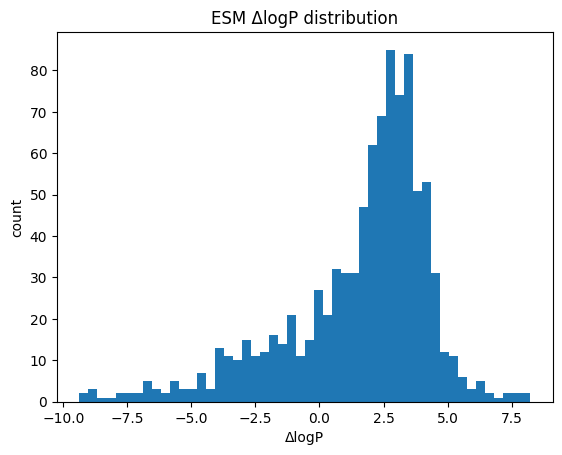

In [17]:
# -------------------------------
# ESM single-mutation scan
# (reusable, cached, scenario-aware, WT-indexed output)
# -------------------------------

import time
import torch
import pandas as pd
import esm
import matplotlib.pyplot as plt
from pathlib import Path


# Amino acids to consider (exclude Cys by default)
AA_LIST = list("ADEFGHIKLMNPQRSTVWY")


# -------------------------------------------------
# Load ESM model
# -------------------------------------------------

def load_esm_model():
    """
    Load pretrained ESM-1b model and alphabet.
    """
    model, alphabet = esm.pretrained.esm1b_t33_650M_UR50S()
    model.eval()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = model.to(device)

    batch_converter = alphabet.get_batch_converter()
    torch.set_grad_enabled(False)

    return model, alphabet, batch_converter, device


# -------------------------------------------------
# Tokenization helper
# -------------------------------------------------

def tokenize_sequence(seq_str, batch_converter, device):
    """
    Tokenize a single protein sequence for ESM.
    """
    data = [("target", seq_str)]
    _, _, batch_tokens = batch_converter(data)
    return batch_tokens.to(device)


# -------------------------------------------------
# Score a single mutation
# -------------------------------------------------

def score_single_mutation(
    model,
    alphabet,
    batch_tokens,
    position,   # 1-based TARGET index
    wt_aa,
    mut_aa,
):
    """
    Compute ΔlogP for a single amino-acid substitution.
    """
    mutated_tokens = batch_tokens.clone()
    mutated_tokens[0, position] = alphabet.get_idx(mut_aa)

    with torch.no_grad():
        logits = model(mutated_tokens)["logits"]
        log_probs = torch.log_softmax(logits[0, position], dim=-1)

    wt_token = alphabet.get_idx(wt_aa)
    mut_token = alphabet.get_idx(mut_aa)

    return log_probs[mut_token].item() - log_probs[wt_token].item()


# -------------------------------------------------
# Run full single-mutation scan (WT-indexed output)
# -------------------------------------------------

def run_esm_single_mutation_scan(
    target_seq_str,
    candidate_positions,
    model,
    alphabet,
    batch_converter,
    device,
    progress=True,
):
    """
    Run ESM single-mutation scan for selected target positions.
    """
    batch_tokens = tokenize_sequence(
        target_seq_str,
        batch_converter,
        device,
    )

    results = []
    start_time = time.time()
    n_positions = len(candidate_positions)

    for i, target_pos in enumerate(candidate_positions, start=1):
        wt_aa = target_seq_str[target_pos - 1]
        wt_pos = target_to_wt_residue_idx(target_pos)

        if progress:
            elapsed = (time.time() - start_time) / 60
            print(
                f"[{i:3d}/{n_positions}] "
                f"WT position {wt_pos:4d} ({wt_aa}) | "
                f"elapsed: {elapsed:.1f} min",
                flush=True,
            )

        for mut_aa in AA_LIST:
            if mut_aa == wt_aa:
                continue

            delta_logp = score_single_mutation(
                model=model,
                alphabet=alphabet,
                batch_tokens=batch_tokens,
                position=target_pos,
                wt_aa=wt_aa,
                mut_aa=mut_aa,
            )

            results.append({
                "wt_idx": wt_pos,
                "wt_aa": wt_aa,
                "mut_aa": mut_aa,
                "delta_logp": round(delta_logp, 3),
            })

    return pd.DataFrame(results)


# -------------------------------------------------
# Scenario-level wrapper (cached WT + scenario copy)
# -------------------------------------------------

def run_esm_scenario(
    target_seq,
    agg_candidate_df,
    model_bundle=None,
    progress=True,
):
    """
    Run or reuse a WT-level ESM single-mutation scan.

    - Canonical cache: results/esm/WT_esm_single_mutations.csv
    - Scenario copy:   results/<SCENARIO>/esm_single_mutations.csv
    """

    # ---- Canonical WT cache ----
    esm_cache_dir = RESULTS_DIR / "esm"
    esm_cache_dir.mkdir(parents=True, exist_ok=True)
    cache_file = esm_cache_dir / "WT_esm_single_mutations.csv"

    # ---- Scenario-local output ----
    outdir = RESULTS_DIR / SCENARIO
    outdir.mkdir(parents=True, exist_ok=True)
    scenario_file = outdir / "esm_single_mutations.csv"

    # ---- Load or compute ----
    if cache_file.exists():
        print(f"Reusing cached ESM scan: {cache_file}")
        esm_df = pd.read_csv(cache_file)
    else:
        print("Running ESM single-mutation scan (WT-level)")

        target_seq_str = str(target_seq.seq)
        candidate_positions = sorted(
            agg_candidate_df["target_idx"].unique()
        )

        if model_bundle is None:
            model, alphabet, batch_converter, device = load_esm_model()
        else:
            model, alphabet, batch_converter, device = model_bundle

        esm_df = run_esm_single_mutation_scan(
            target_seq_str=target_seq_str,
            candidate_positions=candidate_positions,
            model=model,
            alphabet=alphabet,
            batch_converter=batch_converter,
            device=device,
            progress=progress,
        )

        esm_df.to_csv(cache_file, index=False)

        print(f"\nFinished ESM scan (WT-level)")
        print(f"Mutations evaluated: {len(esm_df)}")
        print(f"Cached results to: {cache_file}")

    # ---- Always write scenario-local copy ----
    esm_df.to_csv(scenario_file, index=False)
    print(f"📁 Scenario copy written to: {scenario_file}")

    return esm_df


# -------------------------------------------------
# Execute (safe reuse)
# -------------------------------------------------

esm_df = run_esm_scenario(
    target_seq=target_seq,
    agg_candidate_df=agg_candidate_df,
)

display(esm_df.head())


# -------------------------------------------------
# Quick sanity plot
# -------------------------------------------------

plt.hist(esm_df["delta_logp"], bins=50)
plt.xlabel("ΔlogP")
plt.ylabel("count")
plt.title("ESM ΔlogP distribution")
plt.show()

In [18]:
# -------------------------------------
# 18) Filter ESM mutations
# -------------------------------------

import pandas as pd


# -------------------------------------------------
# Amino-acid chemistry classes
# -------------------------------------------------

# Expected to be defined earlier:
# HYDROPHOBIC_1 = set("AILMFWV")
# AROMATIC_1    = set("FWY")

CHARGED_1 = {"D", "E", "K", "R"}


# -------------------------------------------------
# Index conversion helper
# -------------------------------------------------

def ensure_wt_index(df):
    '''
    Ensure dataframe has a wt_idx column.
    Converts from target_idx if needed.
    '''
    if "wt_idx" not in df.columns:
        df = df.copy()
        df["wt_idx"] = df["target_idx"].apply(target_to_wt_residue_idx)
    return df


# -------------------------------------------------
# Chemistry annotation helpers
# -------------------------------------------------

def annotate_mutation_chemistry(df):
    '''
    Annotate basic chemical properties of mutations.
    All indexing is WT-based.
    '''
    df = df.copy()

    df["is_charged_mut"] = df["mut_aa"].isin(CHARGED_1)

    df["hydrophobic_to_polar"] = (
        df["wt_aa"].isin(HYDROPHOBIC_1)
        & (~df["mut_aa"].isin(HYDROPHOBIC_1))
    )

    df["aromatic_gain"] = (
        (~df["wt_aa"].isin(AROMATIC_1))
        & (df["mut_aa"].isin(AROMATIC_1))
    )

    df["aromatic_loss"] = (
        (df["wt_aa"].isin(AROMATIC_1))
        & (~df["mut_aa"].isin(AROMATIC_1))
    )

    return df


# -------------------------------------------------
# Core filtering logic
# -------------------------------------------------

def filter_esm_mutations(
    esm_df,
    agg_candidate_df,
    delta_logp_cutoff=0.0,
):
    '''
    Apply plausibility and prioritization filters to ESM mutations.
    '''
    # Basic ESM plausibility
    filtered_df = esm_df.loc[
        esm_df["delta_logp"] > delta_logp_cutoff
    ].copy()

    # Annotate chemistry
    filtered_df = annotate_mutation_chemistry(filtered_df)

    # Ensure WT indexing on structural priorities
    agg_df = ensure_wt_index(agg_candidate_df)

    # Merge mutation-priority context (WT space)
    filtered_df = filtered_df.merge(
        agg_df[["wt_idx", "mutation_priority_score"]],
        on="wt_idx",
        how="left"
    )

    # Sort for inspection
    filtered_df = filtered_df.sort_values(
        by=["delta_logp", "mutation_priority_score"],
        ascending=False
    )

    return filtered_df


# -------------------------------------------------
# Scenario-level wrapper
# -------------------------------------------------

def run_esm_filtering_scenario(
    agg_candidate_df,
    delta_logp_cutoff=0.0,
):
    '''
    Load ESM results, filter plausible mutations,
    and export annotated table for the active scenario.
    '''
    indir = RESULTS_DIR / SCENARIO
    infile = indir / "esm_single_mutations.csv"
    outfile = indir / "esm_filtered_single_mutations.csv"

    esm_df = pd.read_csv(infile)

    filtered_df = filter_esm_mutations(
        esm_df=esm_df,
        agg_candidate_df=agg_candidate_df,
        delta_logp_cutoff=delta_logp_cutoff,
    )

    filtered_df.to_csv(outfile, index=False)

    print(f"ESM filtering ({SCENARIO})")
    print(f"ΔlogP cutoff: {delta_logp_cutoff}")
    print(f"Kept mutations: {len(filtered_df)}")
    print(f"Wrote filtered mutations to: {outfile}")

    return filtered_df


# -------------------------------------------------
# Execute (basecase)
# -------------------------------------------------

filtered_esm_df = run_esm_filtering_scenario(
    agg_candidate_df=agg_candidate_df,
    delta_logp_cutoff=0.0,
)

filtered_esm_df.head(15)

ESM filtering (06_strict_surface)
ΔlogP cutoff: 0.0
Kept mutations: 726
Wrote filtered mutations to: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/esm_filtered_single_mutations.csv


,wt_idx,wt_aa,mut_aa,delta_logp,is_charged_mut,hydrophobic_to_polar,aromatic_gain,aromatic_loss,mutation_priority_score
691,267,G,V,8.231,False,False,False,False,NaN
680,267,G,F,7.929,False,False,True,False,NaN
684,267,G,L,7.709,False,False,False,False,NaN
682,267,G,I,7.659,False,False,False,False,NaN
690,267,G,T,7.349,False,False,False,False,NaN
10,15,N,P,7.217,False,False,False,False,0.093750
685,267,G,M,7.009,False,False,False,False,NaN
264,157,Y,D,6.599,True,False,False,True,0.125000
643,241,C,K,6.472,True,False,False,False,0.090909
636,241,C,A,6.389,False,False,False,False,0.090909


In [19]:
# -------------------------------------
# 19) Rank ESM mutations
# -------------------------------------

import pandas as pd
import numpy as np


# -------------------------------------------------
# Utility: min–max normalization
# -------------------------------------------------

def minmax(series):
    '''
    Min–max normalize a pandas Series.
    '''
    return (series - series.min()) / (series.max() - series.min() + 1e-8)


# -------------------------------------------------
# Ensure WT indexing
# -------------------------------------------------

def ensure_wt_index(df):
    '''
    Ensure dataframe has a wt_idx column.
    Converts from target_idx if needed.
    '''
    if "wt_idx" not in df.columns:
        if "target_idx" not in df.columns:
            raise KeyError("Neither wt_idx nor target_idx found in dataframe")

        df = df.copy()
        df["wt_idx"] = df["target_idx"].apply(target_to_wt_residue_idx)

    return df


# -------------------------------------------------
# Core ranking logic
# -------------------------------------------------

def rank_esm_mutations(
    esm_filtered_df,
    w_esm,
    w_struct,
):
    '''
    Rank ESM-filtered single mutations using a weighted score.
    Output is WT-indexed.
    '''
    df = ensure_wt_index(esm_filtered_df)

    # Normalize components
    df["norm_delta_logp"] = minmax(df["delta_logp"])
    df["norm_priority"]  = minmax(df["mutation_priority_score"])

    # Final weighted score
    df["final_score"] = (
        w_esm    * df["norm_delta_logp"] +
        w_struct * df["norm_priority"]
    )

    return df.sort_values("final_score", ascending=False)


# -------------------------------------------------
# Scenario-level wrapper
# -------------------------------------------------

def run_esm_ranking_scenario(
    w_esm=W_ESM,
    w_struct=W_STRUCT,
):
    '''
    Rank ESM mutations for the active SCENARIO.
    '''
    indir   = RESULTS_DIR / SCENARIO
    infile  = indir / "esm_filtered_single_mutations.csv"
    outfile = indir / "esm_ranked_single_mutations.csv"

    # Load filtered ESM mutations
    esm_df = pd.read_csv(infile)

    # Rank
    ranked_df = rank_esm_mutations(
        esm_filtered_df=esm_df,
        w_esm=w_esm,
        w_struct=w_struct,
    )

    # Export
    ranked_df.to_csv(outfile, index=False)

    print(f"ESM ranking ({SCENARIO})")
    print(f"w_esm={w_esm}, w_struct={w_struct}")
    print(f"Ranked mutations: {len(ranked_df)}")
    print(f"Wrote ranked mutations to: {outfile}")

    return ranked_df


# -------------------------------------------------
# Execute
# -------------------------------------------------

ranked_df = run_esm_ranking_scenario()

ranked_df.head(20)

ESM ranking (06_strict_surface)
w_esm=0.6, w_struct=0.4
Ranked mutations: 726
Wrote ranked mutations to: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/esm_ranked_single_mutations.csv


,wt_idx,wt_aa,mut_aa,delta_logp,is_charged_mut,hydrophobic_to_polar,aromatic_gain,aromatic_loss,mutation_priority_score,norm_delta_logp,norm_priority,final_score
62,171,A,F,4.484,False,False,True,False,0.62000,0.544548,1.000000,0.726729
135,171,A,L,3.952,False,False,False,False,0.62000,0.479883,1.000000,0.687930
234,171,A,Y,3.413,False,True,True,False,0.62000,0.414367,1.000000,0.648620
324,171,A,I,3.025,False,False,False,False,0.62000,0.367206,1.000000,0.620323
328,171,A,S,3.013,False,True,False,False,0.62000,0.365747,1.000000,0.619448
359,171,A,K,2.864,True,True,False,False,0.62000,0.347636,1.000000,0.608581
363,171,A,M,2.846,False,False,False,False,0.62000,0.345448,1.000000,0.607269
369,171,A,V,2.832,False,False,False,False,0.62000,0.343746,1.000000,0.606248
381,171,A,W,2.756,False,False,True,False,0.62000,0.334508,1.000000,0.600705
382,171,A,T,2.754,False,True,False,False,0.62000,0.334265,1.000000,0.600559


In [20]:
# -------------------------------------
# 20) Select top single mutations for design
# -------------------------------------

import pandas as pd

# -------------------------------
# Design selection parameters
# -------------------------------
TOP_N_PER_POSITION = 3
MIN_FINAL_SCORE    = 0.5


# -------------------------------------------------
# Core selection logic
# -------------------------------------------------

def select_design_mutations(
    ranked_df,
    top_n_per_position,
    min_final_score,
):
    '''
    Select top-ranked single-site mutations for experimental design.
    All grouping is done in WT index space.
    '''
    # Score filter
    df = ranked_df.loc[
        ranked_df["final_score"] >= min_final_score
    ].copy()

    # Top-N per WT position
    df = (
        df
        .sort_values(
            by=["wt_idx", "final_score"],
            ascending=[True, False]
        )
        .groupby("wt_idx", as_index=False)
        .head(top_n_per_position)
    )

    # Global ranking
    return df.sort_values("final_score", ascending=False)


# -------------------------------------------------
# Scenario-level wrapper
# -------------------------------------------------

def run_design_selection_scenario(
    top_n_per_position=TOP_N_PER_POSITION,
    min_final_score=MIN_FINAL_SCORE,
):
    '''
    Select design mutations for the active SCENARIO.
    '''
    indir   = RESULTS_DIR / SCENARIO
    infile  = indir / "esm_ranked_single_mutations.csv"
    outfile = indir / "design_single_mutations.csv"

    ranked_df = pd.read_csv(infile)

    design_df = select_design_mutations(
        ranked_df=ranked_df,
        top_n_per_position=top_n_per_position,
        min_final_score=min_final_score,
    )

    design_df.to_csv(outfile, index=False)

    print(f"Design mutation selection ({SCENARIO})")
    print(f"Min final score: {min_final_score}")
    print(f"Top N per WT position: {top_n_per_position}")
    print(f"Selected mutations: {len(design_df)}")
    print(f"Wrote curated mutations to: {outfile}")

    return design_df


# -------------------------------------------------
# Execute (basecase)
# -------------------------------------------------

design_df = run_design_selection_scenario()

design_df.head(20)

Design mutation selection (06_strict_surface)
Min final score: 0.5
Top N per WT position: 3
Selected mutations: 5
Wrote curated mutations to: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/design_single_mutations.csv


,wt_idx,wt_aa,mut_aa,delta_logp,is_charged_mut,hydrophobic_to_polar,aromatic_gain,aromatic_loss,mutation_priority_score,norm_delta_logp,norm_priority,final_score
0,171,A,F,4.484,False,False,True,False,0.62000,0.544548,1.000000,0.726729
1,171,A,L,3.952,False,False,False,False,0.62000,0.479883,1.000000,0.687930
2,171,A,Y,3.413,False,True,True,False,0.62000,0.414367,1.000000,0.648620
16,15,N,P,7.217,False,False,False,False,0.09375,0.876747,0.010371,0.530197
18,157,Y,D,6.599,True,False,False,True,0.12500,0.801629,0.069137,0.508632


# Double-mutation Variant Selection

In [21]:
# -------------------------------------
# 21) Build multi-mutation variants
# -------------------------------------

import itertools
import pandas as pd
import sys
from pathlib import Path


# -------------------------------
# Global parameters
# -------------------------------
N_MUTATIONS_PER_VARIANT = 2
MAX_VARIANTS            = 200
MIN_POSITION_SEPARATION = 5


# -------------------------------------------------
# Load curated single mutations
# -------------------------------------------------

def load_design_single_mutations():
    '''
    Load curated single-site design mutations for the active SCENARIO.
    '''
    infile = RESULTS_DIR / SCENARIO / "design_single_mutations.csv"
    return pd.read_csv(infile)


# -------------------------------------------------
# Group mutations by WT position
# -------------------------------------------------

def group_mutations_by_wt_position(single_df):
    '''
    Group single mutations by WT residue index.
    '''
    return {
        pos: grp.to_dict("records")
        for pos, grp in single_df.groupby("wt_idx")
    }


# -------------------------------------------------
# Check minimum spacing constraint (WT space)
# -------------------------------------------------

def passes_spacing_constraint(
    positions,
    min_separation=MIN_POSITION_SEPARATION,
):
    '''
    Ensure all mutation positions are sufficiently separated (WT indexing).
    '''
    return not any(
        abs(p1 - p2) < min_separation
        for p1, p2 in itertools.combinations(positions, 2)
    )


# -------------------------------------------------
# Generate multi-mutation variants
# -------------------------------------------------

def build_multi_mutation_variants(
    by_position,
    n_mutations=N_MUTATIONS_PER_VARIANT,
    max_variants=MAX_VARIANTS,
):
    '''
    Generate multi-mutation variants from curated single mutations.
    '''
    positions = sorted(by_position.keys())
    variants = []

    for pos_combo in itertools.combinations(positions, n_mutations):

        # Enforce spatial separation
        if not passes_spacing_constraint(pos_combo):
            continue

        for muts in itertools.product(
            *[by_position[p] for p in pos_combo]
        ):
            mut_labels = [
                f"{m['wt_aa']}{pos}{m['mut_aa']}"
                for m, pos in zip(muts, pos_combo)
            ]

            scores = [m["final_score"] for m in muts]

            variants.append({
                "variant": "_".join(mut_labels),
                "n_mutations": len(muts),
                "wt_positions": ",".join(map(str, pos_combo)),
                "mean_score": sum(scores) / len(scores),
                "sum_score": sum(scores),
            })

            if len(variants) >= max_variants:
                return pd.DataFrame(variants)

    return pd.DataFrame(variants)


# -------------------------------------------------
# Scenario-level wrapper (Option A termination)
# -------------------------------------------------

def run_multi_mutation_scenario(
    n_mutations=N_MUTATIONS_PER_VARIANT,
    max_variants=MAX_VARIANTS,
):
    '''
    Build and export WT-indexed multi-mutation variants for SCENARIO.
    Terminates the run if no valid variants exist.
    '''
    outdir = RESULTS_DIR / SCENARIO
    outdir.mkdir(parents=True, exist_ok=True)

    outfile = outdir / "multi_mutation_variants.csv"
    stopfile = outdir / "run_terminated.txt"

    single_df = load_design_single_mutations()
    by_position = group_mutations_by_wt_position(single_df)

    variant_df = build_multi_mutation_variants(
        by_position=by_position,
        n_mutations=n_mutations,
        max_variants=max_variants,
    )

    # -------------------------------
    # HARD STOP: no valid variants
    # -------------------------------
    if variant_df.empty:
        message = (
            f"RUN TERMINATED — SCENARIO: {SCENARIO}\n\n"
            f"No valid multi-mutation variants could be generated.\n\n"
            f"Reason:\n"
            f"- All curated single mutations are clustered in WT space\n"
            f"- MIN_POSITION_SEPARATION = {MIN_POSITION_SEPARATION}\n"
            f"- N_MUTATIONS_PER_VARIANT = {n_mutations}\n\n"
            f"This is expected behavior for a locally saturated design space.\n"
            f"No downstream analysis was executed.\n"
        )

        stopfile.write_text(message)

        print("\n" + "=" * 70)
        print("PIPELINE TERMINATED (EXPECTED CONDITION)")
        print(message.strip())
        print(f"Log written to: {stopfile}")
        print("=" * 70 + "\n")

        # Terminate entire notebook run
        sys.exit(0)

    # -------------------------------
    # Normal path (variants exist)
    # -------------------------------
    variant_df = variant_df.sort_values(
        "sum_score", ascending=False
    )

    variant_df.to_csv(outfile, index=False)

    print(f"Multi-mutation variant generation ({SCENARIO})")
    print(f"Mutations per variant: {n_mutations}")
    print(f"Built variants: {len(variant_df)}")
    print(f"Wrote variants to: {outfile}")

    return variant_df


# -------------------------------------------------
# Execute
# -------------------------------------------------

variant_df = run_multi_mutation_scenario()
variant_df.head(20)

Multi-mutation variant generation (06_strict_surface)
Mutations per variant: 2
Built variants: 7
Wrote variants to: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/multi_mutation_variants.csv


,variant,n_mutations,wt_positions,mean_score,sum_score
1,N15P_A171F,2,"15,171",0.628463,1.256926
4,Y157D_A171F,2,"157,171",0.617681,1.235361
2,N15P_A171L,2,"15,171",0.609063,1.218127
5,Y157D_A171L,2,"157,171",0.598281,1.196562
3,N15P_A171Y,2,"15,171",0.589408,1.178817
6,Y157D_A171Y,2,"157,171",0.578626,1.157253
0,N15P_Y157D,2,"15,157",0.519414,1.038829


In [22]:
# -------------------------------------
# 22) Select top multi-mutation variants
# -------------------------------------

import pandas as pd

TOP_K_VARIANTS = 20        # how many variants to carry forward
MIN_MEAN_SCORE = 0.5       # optional quality gate

# -------------------------------------------------
# Core selection logic
# -------------------------------------------------

def select_top_multi_mutation_variants(
    variant_df,
    top_k=TOP_K_VARIANTS,
    min_mean_score=MIN_MEAN_SCORE,
):
    '''
    Filter and rank multi-mutation variants for final selection.
    '''
    df = variant_df.loc[
        variant_df["mean_score"] >= min_mean_score
    ].copy()

    return (
        df
        .sort_values("sum_score", ascending=False)
        .head(top_k)
    )


# -------------------------------------------------
# Scenario-level wrapper
# -------------------------------------------------

def run_multi_variant_selection_scenario(
    top_k=TOP_K_VARIANTS,
    min_mean_score=MIN_MEAN_SCORE,
):
    '''
    Select top multi-mutation variants for a given scenario.
    '''
    indir = RESULTS_DIR / SCENARIO
    infile = indir / "multi_mutation_variants.csv"
    outfile = indir / "selected_multi_mutation_variants.csv"

    variant_df = pd.read_csv(infile)

    selected_df = select_top_multi_mutation_variants(
        variant_df=variant_df,
        top_k=top_k,
        min_mean_score=min_mean_score,
    )

    selected_df.to_csv(outfile, index=False)

    print(f"Multi-mutation variant selection ({SCENARIO})")
    print(f"Min mean score: {min_mean_score}")
    print(f"Top K variants: {top_k}")
    print(f"Selected variants: {len(selected_df)}")
    print(f"Wrote final design set to: {outfile}")

    return selected_df


# -------------------------------------------------
# Execute (basecase)
# -------------------------------------------------

selected_variants_df = run_multi_variant_selection_scenario()

selected_variants_df

Multi-mutation variant selection (06_strict_surface)
Min mean score: 0.5
Top K variants: 20
Selected variants: 7
Wrote final design set to: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/selected_multi_mutation_variants.csv


,variant,n_mutations,wt_positions,mean_score,sum_score
0,N15P_A171F,2,"15,171",0.628463,1.256926
1,Y157D_A171F,2,"157,171",0.617681,1.235361
2,N15P_A171L,2,"15,171",0.609063,1.218127
3,Y157D_A171L,2,"157,171",0.598281,1.196562
4,N15P_A171Y,2,"15,171",0.589408,1.178817
5,Y157D_A171Y,2,"157,171",0.578626,1.157253
6,N15P_Y157D,2,"15,157",0.519414,1.038829


In [23]:
# -------------------------------------
# 23) Construct variant sequences
# -------------------------------------

from pathlib import Path
import pandas as pd
from Bio import SeqIO

# -------------------------------------------------
# Extract TARGET sequence from A3M
# -------------------------------------------------

def extract_target_sequence_from_a3m(a3m_path):
    record = next(SeqIO.parse(a3m_path, "fasta"))
    # Remove alignment gaps just in case
    return str(record.seq).replace("-", "")


# -------------------------------------------------
# Apply WT-indexed mutations to TARGET sequence
# -------------------------------------------------

def apply_wt_indexed_mutations_to_target(
    target_seq_str,
    variant_label,
):
    '''
    Apply mutations defined in WT indexing to the TARGET sequence.

    Example variant_label:
        "E165L_A169F"
    '''
    seq_list = list(target_seq_str)

    for mut in variant_label.split("_"):
        wt_aa = mut[0]
        wt_idx = int(mut[1:-1])     # WT index (1-based)
        mut_aa = mut[-1]

        target_idx = wt_to_target_residue_idx(wt_idx)

        # Optional sanity check
        current_aa = seq_list[target_idx - 1]
        if current_aa != wt_aa:
            print(
                f"WARNING: {mut} expected {wt_aa}, "
                f"found {current_aa} at TARGET position {target_idx}"
            )

        seq_list[target_idx - 1] = mut_aa

    return "".join(seq_list)


# -------------------------------------------------
# Build FASTA records
# -------------------------------------------------

def build_variant_fasta_records(
    variant_df,
    target_seq_str,
):
    '''
    Construct FASTA records for multi-mutation variants.
    '''
    records = []

    for i, row in variant_df.iterrows():
        variant_id = f"VAR_{i+1:02d}"
        variant_label = row["variant"]

        variant_seq = apply_wt_indexed_mutations_to_target(
            target_seq_str=target_seq_str,
            variant_label=variant_label,
        )

        header = (
            f">{variant_id} | {variant_label} | "
            f"sum_score={row['sum_score']:.3f} | "
            f"mean_score={row['mean_score']:.3f}"
        )

        records.append(header)
        records.append(variant_seq)

    return records


# -------------------------------------------------
# Scenario-level wrapper (GLOBAL SCENARIO)
# -------------------------------------------------

def run_variant_fasta_construction():
    '''
    Build FASTA sequences for selected multi-mutation variants.
    '''
    indir = RESULTS_DIR / SCENARIO
    infile = indir / "selected_multi_mutation_variants.csv"
    outfile = indir / "variant_sequences.fasta"

    # A3M containing the TARGET query sequence
    TARGET_A3M = Path("fasta/AF-A0A515BEI4-F1-msa_v6.a3m")

    variant_df = pd.read_csv(infile)

    # 🔑 Authoritative reference sequence
    target_seq_str = extract_target_sequence_from_a3m(TARGET_A3M)

    records = build_variant_fasta_records(
        variant_df=variant_df,
        target_seq_str=target_seq_str,
    )

    outfile.parent.mkdir(parents=True, exist_ok=True)
    outfile.write_text("\n".join(records))

    print(f"Variant FASTA construction ({SCENARIO})")
    print(f"Variants written: {len(variant_df)}")
    print(f"Target length (A3M query): {len(target_seq_str)}")
    print(f"Output FASTA: {outfile}")
    print("\nPreview:\n")
    print("\n".join(records[:4]))

    return outfile


# -------------------------------------------------
# Execute
# -------------------------------------------------

fasta_path = run_variant_fasta_construction()

Variant FASTA construction (06_strict_surface)
Variants written: 7
Target length (A3M query): 272
Output FASTA: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/variant_sequences.fasta

Preview:

>VAR_01 | N15P_A171F | sum_score=1.257 | mean_score=0.628
QKITPPSQEDWVPSKKYLKINDQVEMAYVEWGNPSGEPIFLIHGYSDSSRAYSTVAPLLQGARFIAPDLRGHGNTTAPNGAYGIQCLAEDISDFIDALGYKRAKVVGHSMGSLTAGLLASFYPEKVEKLILISSAVKMNPDVSKWLYEQIVTFAYPTDPNNGWLEREWFGNPNGIFDDVMMKLLRKEQAAMPQRVWASLLKAMDTLDWSHAARHITAPTLIMWGDQDTLMTEAEQGPLCQAIPHAIFKRYEGKGHSMYWEDPQEGANDIMDF
>VAR_02 | Y157D_A171F | sum_score=1.235 | mean_score=0.618
QKITPPSQEDWVNSKKYLKINDQVEMAYVEWGNPSGEPIFLIHGYSDSSRAYSTVAPLLQGARFIAPDLRGHGNTTAPNGAYGIQCLAEDISDFIDALGYKRAKVVGHSMGSLTAGLLASFYPEKVEKLILISSAVKMNPDVSKWLYEQIVTFADPTDPNNGWLEREWFGNPNGIFDDVMMKLLRKEQAAMPQRVWASLLKAMDTLDWSHAARHITAPTLIMWGDQDTLMTEAEQGPLCQAIPHAIFKRYEGKGHSMYWEDPQEGANDIMDF


In [24]:
# -------------------------------------------------
# 24) Construct per-variant Multiple Sequence Alignment .a3m's
# -------------------------------------------------

from pathlib import Path


def load_template_a3m_lines(a3m_path):
    """
    Load template A3M as raw lines.
    """
    with open(a3m_path) as f:
        lines = [line.rstrip("\n") for line in f]

    return lines[0], lines[1], lines[2:]


def load_variant_fasta_pairs(fasta_path):
    """
    Load variant FASTA:
    """
    with open(fasta_path) as f:
        lines = [line.strip() for line in f if line.strip()]

    variants = []

    for header, seq in zip(lines[0::2], lines[1::2]):
        if not header.startswith(">"):
            raise ValueError(f"Invalid FASTA header: {header}")

        parts = [p.strip() for p in header[1:].split("|")]
        variant_id = parts[0]      # VAR_01
        mutation   = parts[1]      # E167L_G267V

        variants.append((variant_id, mutation, seq))

    return variants


def run_variant_a3m_construction():
    """
    Replace the first entry of a template A3M
    with each variant sequence and write per-variant MSAs.
    """
    template_a3m = Path("fasta/AF-A0A515BEI4-F1-msa_v6.a3m")
    variant_fasta = RESULTS_DIR / SCENARIO / "variant_sequences.fasta"
    outdir = RESULTS_DIR / SCENARIO / "a3m"

    outdir.mkdir(parents=True, exist_ok=True)

    # Load template once
    tpl_header, tpl_seq, tpl_rest = load_template_a3m_lines(template_a3m)

    # Load variants
    variants = load_variant_fasta_pairs(variant_fasta)

    print(f"A3M construction ({SCENARIO})")
    print(f"Template A3M: {template_a3m}")
    print(f"Template length: {len(tpl_seq)} aa")
    print(f"Variants loaded: {len(variants)}")
    print(f"Output directory: {outdir}\n")

    for i, (variant_id, mutation, var_seq) in enumerate(variants, start=1):
        # Hard safety check
        if len(var_seq) != len(tpl_seq):
            raise ValueError(
                f"Length mismatch for {variant_id}: "
                f"{len(var_seq)} vs {len(tpl_seq)}"
            )

        out_path = outdir / f"{variant_id}_{mutation}.a3m"

        with out_path.open("w") as f:
            # Replace query
            f.write(f">query\n")
            f.write(var_seq + "\n")

            # Keep all references untouched
            for line in tpl_rest:
                f.write(line + "\n")

        print(f"[{i:3d}/{len(variants)}] wrote {out_path.name}")

    print(f"\nDone. Wrote {len(variants)} A3M files to {outdir}")


# -------------------------------------------------
# Execute
# -------------------------------------------------

run_variant_a3m_construction()

A3M construction (06_strict_surface)
Template A3M: fasta/AF-A0A515BEI4-F1-msa_v6.a3m
Template length: 272 aa
Variants loaded: 7
Output directory: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/a3m

[  1/7] wrote VAR_01_N15P_A171F.a3m
[  2/7] wrote VAR_02_Y157D_A171F.a3m
[  3/7] wrote VAR_03_N15P_A171L.a3m
[  4/7] wrote VAR_04_Y157D_A171L.a3m
[  5/7] wrote VAR_05_N15P_A171Y.a3m
[  6/7] wrote VAR_06_Y157D_A171Y.a3m
[  7/7] wrote VAR_07_N15P_Y157D.a3m

Done. Wrote 7 A3M files to /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/a3m


# Structure Folding using Openfold2 on NVIDIA NIM

In [ ]:
# -------------------------------------------------
# Fold variants with OpenFold2 (scenario-aware)
# Robust for large A3Ms (~7 MB)
# WITH cross-scenario PDB reuse
# -------------------------------------------------

import os
import time
import requests
from pathlib import Path
from Bio import SeqIO
from dotenv import load_dotenv
from requests.exceptions import SSLError, ConnectionError, Timeout

load_dotenv()

# ----------------------------
# Config (uses globals safely)
# ----------------------------
API_URL = (
    "https://health.api.nvidia.com/v1/biology/openfold/"
    "openfold2/predict-structure-from-msa-and-template"
)
API_KEY = os.environ["NVIDIA_API_KEY"]

HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Content-Type": "application/json",
    "NVCF-POLL-SECONDS": "300",
}

VARIANT_FASTA = RESULTS_DIR / SCENARIO / "variant_sequences.fasta"
A3M_DIR = RESULTS_DIR / SCENARIO / "a3m"
VARIANTS_PDB_DIR = RESULTS_DIR / SCENARIO / "pdb"

A3M_DIR.mkdir(parents=True, exist_ok=True)
VARIANTS_PDB_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# HTTP session
# ----------------------------
session = requests.Session()
session.headers.update(HEADERS)

# -------------------------------------------------
# Variant FASTA header parsing
# -------------------------------------------------

def parse_variant_header(record):
    """
    Supported headers:
    >VAR_01 | E167L_G267V | sum_score=... | mean_score=...
    >VAR_01 | E167L_G267V
    """
    parts = [p.strip() for p in record.description.split("|")]
    if len(parts) < 2:
        raise ValueError(f"Malformed variant header: {record.description}")
    return parts[0], parts[1].replace(" ", "")

# -------------------------------------------------
# Cross-scenario PDB reuse helpers
# -------------------------------------------------

def extract_mutation_from_stem(stem: str) -> str | None:
    """
    VAR_01_E167L_G267V → E167L_G267V
    VAR_12_N15P_E167L → N15P_E167L
    """
    parts = stem.split("_")
    if len(parts) < 3:
        return None
    return "_".join(parts[2:])


def rewrite_pdb_metadata(pdb_text: str, new_id: str) -> str:
    """
    Update HEADER / TITLE / REMARK lines only.
    Coordinates remain untouched.
    """
    out = []
    for line in pdb_text.splitlines():
        if line.startswith(("HEADER", "TITLE", "REMARK")):
            out.append(line[:10] + new_id.ljust(70))
        else:
            out.append(line)
    return "\n".join(out) + "\n"


def try_reuse_existing_pdb(
    mutation: str,
    new_stem: str,
    dest_dir: Path,
) -> bool:
    """
    Look in RESULTS_DIR/*/pdb for a PDB with the same mutation.
    Copy + rename + rewrite metadata if found.
    """
    for scenario_dir in RESULTS_DIR.iterdir():
        if not scenario_dir.is_dir() or scenario_dir.name == SCENARIO:
            continue

        pdb_dir = scenario_dir / "pdb"
        if not pdb_dir.exists():
            continue

        for pdb in pdb_dir.glob("VAR_*.pdb"):
            old_mut = extract_mutation_from_stem(pdb.stem)

            if old_mut == mutation:
                new_path = dest_dir / f"{new_stem}.pdb"
                rewritten = rewrite_pdb_metadata(
                    pdb.read_text(),
                    new_stem,
                )
                new_path.write_text(rewritten)

                print(
                    f"Reused PDB from '{scenario_dir.name}': "
                    f"{pdb.name} → {new_path.name}",
                    flush=True,
                )
                return True

    return False

# -------------------------------------------------
# OpenFold helpers
# -------------------------------------------------

def fold_variant(name, sequence, a3m_text, max_retries=8):
    payload = {
        "sequence": sequence,
        "alignments": {
            "small_bfd": {
                "a3m": {"alignment": a3m_text, "format": "a3m"}
            }
        },
        "selected_models": [1],
        "relax_prediction": False,
    }

    backoff = 10

    for attempt in range(1, max_retries + 1):
        try:
            r = session.post(API_URL, json=payload, timeout=900)

            if r.status_code == 200:
                return r.json()

            if r.status_code in (429, 500, 502, 503, 504):
                print(
                    f"WARNING {name}: server {r.status_code}, "
                    f"retry {attempt}/{max_retries} in {backoff}s",
                    flush=True,
                )
                time.sleep(backoff)
                backoff = int(backoff * 1.5)
                continue

            raise RuntimeError(f"{name} failed ({r.status_code}): {r.text}")

        except (SSLError, ConnectionError, Timeout) as e:
            print(
                f"WARNING {name}: {type(e).__name__}, "
                f"retry {attempt}/{max_retries} in {backoff}s",
                flush=True,
            )
            time.sleep(backoff)
            backoff = int(backoff * 1.5)

    raise RuntimeError(f"{name} failed after {max_retries} retries")


def extract_pdb(result_json):
    return result_json["structures_in_ranked_order"][0]["structure"]

# -------------------------------------------------
# Main folding loop
# -------------------------------------------------

records = list(SeqIO.parse(VARIANT_FASTA, "fasta"))
n = len(records)

print(f"Folding variants ({SCENARIO})")
print(f"Variants: {n}")
print(f"A3M size ~ {round(next(A3M_DIR.glob('*.a3m')).stat().st_size / 1e6, 2)} MB\n")

for i, record in enumerate(records, start=1):
    variant_id, mutation = parse_variant_header(record)
    stem = f"{variant_id}_{mutation}"
    seq = str(record.seq)

    pdb_path = VARIANTS_PDB_DIR / f"{stem}.pdb"
    a3m_path = A3M_DIR / f"{stem}.a3m"

    # Already present
    if pdb_path.exists():
        print(f"[{i}/{n}] Skipping {stem} (already present)")
        continue

    # Try reuse
    if try_reuse_existing_pdb(mutation, stem, VARIANTS_PDB_DIR):
        continue

    # Fold
    if not a3m_path.exists():
        raise FileNotFoundError(f"Missing A3M for {stem}")

    print(f"[{i}/{n}] Folding {stem}", flush=True)
    result = fold_variant(stem, seq, a3m_path.read_text())
    pdb_path.write_text(extract_pdb(result))

    print(f"  → saved {pdb_path.name}", flush=True)
    time.sleep(15)

print("\nAll variant structures generated.")

Folding variants (06_strict_surface)
Variants: 7
A3M size ~ 7.32 MB

[1/7] Folding VAR_01_N15P_A171F
  → saved VAR_01_N15P_A171F.pdb
[2/7] Folding VAR_02_Y157D_A171F
  → saved VAR_02_Y157D_A171F.pdb
[3/7] Folding VAR_03_N15P_A171L
  → saved VAR_03_N15P_A171L.pdb
[4/7] Folding VAR_04_Y157D_A171L
  → saved VAR_04_Y157D_A171L.pdb
[5/7] Folding VAR_05_N15P_A171Y
  → saved VAR_05_N15P_A171Y.pdb
[6/7] Folding VAR_06_Y157D_A171Y
  → saved VAR_06_Y157D_A171Y.pdb
[7/7] Folding VAR_07_N15P_Y157D
  → saved VAR_07_N15P_Y157D.pdb

All variant structures generated.


In [26]:
# -------------------------------------------------
# 26) Structural validation of variants
# -------------------------------------------------

import numpy as np
import pandas as pd
from Bio.PDB import Superimposer

# =========================
# Parameters (pipeline-level)
# =========================

NEAREST_RMSD_CUTOFF = 0.8
COVERAGE_MIN = 0.98

# Reference TARGET structure
TARGET_PDB = PDB_DIR / "A0A515BEI4_alphafold2_model_2_seed_000.pdb"
VARIANTS_PDB_DIR = RESULTS_DIR / SCENARIO / "pdb"

# =========================
# Target-centric metrics
# =========================

def compute_triad_distances(structure):
    """
    Compute catalytic triad CA–CA distances
    using TARGET_CATALYTIC_TRIAD (TARGET indexing).
    """
    chain = get_chain(structure)
    resmap = {
        r.id[1]: r
        for r in chain
        if r.id[0] == " " and "CA" in r
    }

    try:
        a, b, c = [
            resmap[i]["CA"].coord
            for i in TARGET_CATALYTIC_TRIAD
        ]
    except KeyError:
        return None

    return {
        "d_Ser_His": float(np.linalg.norm(a - b)),
        "d_His_Asp": float(np.linalg.norm(b - c)),
        "d_Ser_Asp": float(np.linalg.norm(a - c)),
    }

def rmsd_ca(struct_a, struct_b):
    """
    Direct CA RMSD assuming identical residue ordering and length.
    """
    ca_a = [
        res["CA"] for res in get_chain(struct_a)
        if res.id[0] == " " and "CA" in res
    ]
    ca_b = [
        res["CA"] for res in get_chain(struct_b)
        if res.id[0] == " " and "CA" in res
    ]

    if len(ca_a) != len(ca_b) or len(ca_a) < 10:
        return np.nan

    sup = Superimposer()
    sup.set_atoms(ca_a, ca_b)
    return float(sup.rms)

# =========================
# Variant-level loading
# =========================

def load_variant_struct_df():
    """
    Load variant PDBs only.
    """
    rows = []

    for pdb_file in sorted(VARIANTS_PDB_DIR.glob("*.pdb")):
        structure = parser.get_structure(pdb_file.stem, pdb_file)

        rows.append({
            "variant_id": pdb_file.stem,
            "pdb_file": pdb_file.name,
            "structure": structure,
        })

    return pd.DataFrame(rows)

# =========================
# Variant–variant RMSD
# =========================

def compute_nearest_neighbor_rmsd(struct_df):
    """
    Compute nearest-neighbor RMSD among variants.
    """
    ids = struct_df["variant_id"].tolist()

    rmsd_mat = pd.DataFrame(
        np.nan,
        index=ids,
        columns=ids,
    )

    for i, row_i in struct_df.iterrows():
        for j, row_j in struct_df.iterrows():
            if i >= j:
                continue

            r = rmsd_ca(
                row_i["structure"],
                row_j["structure"],
            )

            rmsd_mat.iloc[i, j] = r
            rmsd_mat.iloc[j, i] = r

    return rmsd_mat.min(axis=1)

# =========================
# Validation table
# =========================

def build_validation_table(variant_struct_df, nearest_variant_rmsd):
    rows = []

    # ---- TARGET ----
    target_struct = parser.get_structure("TARGET", TARGET_PDB)
    tri = compute_triad_distances(target_struct)

    rows.append({
        "variant_id": "TARGET",
        "coverage": 1.0,
        "triad_ok": tri is not None,
        **(tri if tri else {}),
        "target_rmsd": np.nan,
        "nearest_variant_rmsd": np.nan,
        "pdb_path": str(TARGET_PDB),
        "PASS": True,
    })

    # ---- VARIANTS ----
    for _, row in variant_struct_df.iterrows():
        vid = row["variant_id"]
        struct = row["structure"]

        tri = compute_triad_distances(struct)
        nn = nearest_variant_rmsd.get(vid, np.nan)

        target_rmsd = rmsd_ca(struct, target_struct)

        rows.append({
            "variant_id": vid,
            "coverage": 1.0,
            "triad_ok": tri is not None,
            **(tri if tri else {}),
            "target_rmsd": target_rmsd,
            "nearest_variant_rmsd": nn,
            "pdb_path": str(VARIANTS_PDB_DIR / row["pdb_file"]),
            "PASS": (
                (tri is not None)
                and (nn <= NEAREST_RMSD_CUTOFF)
            ),
        })

    df = pd.DataFrame(rows)

    ordered_cols = [
        "variant_id",
        "coverage",
        "triad_ok",
        "d_Ser_His",
        "d_His_Asp",
        "d_Ser_Asp",
        "target_rmsd",
        "nearest_variant_rmsd",
        "pdb_path",
        "PASS",
    ]

    return df[ordered_cols]

# =========================
# Scenario-level wrapper
# =========================

def run_structural_validation_scenario():
    out_csv = RESULTS_DIR / SCENARIO / "variant_structural_validation.csv"

    variant_struct_df = load_variant_struct_df()
    if variant_struct_df.empty:
        raise RuntimeError("No variant structures found.")

    nearest_variant_rmsd = compute_nearest_neighbor_rmsd(
        variant_struct_df
    )

    df = build_validation_table(
        variant_struct_df,
        nearest_variant_rmsd,
    )

    out_csv.parent.mkdir(exist_ok=True)
    df.to_csv(out_csv, index=False)

    print(f"Structural validation ({SCENARIO})")
    print(f"Variants evaluated: {len(df) - 1}")
    print(f"Wrote results to: {out_csv}")

    return (
        df.sort_values(
            ["PASS", "nearest_variant_rmsd"],
            ascending=[False, True],
            na_position="first",
        )
        .reset_index(drop=True)
    )

# =========================
# Execute
# =========================

validation_df = run_structural_validation_scenario()
validation_df

Structural validation (06_strict_surface)
Variants evaluated: 7
Wrote results to: /mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/variant_structural_validation.csv


,variant_id,coverage,triad_ok,d_Ser_His,d_His_Asp,d_Ser_Asp,target_rmsd,nearest_variant_rmsd,pdb_path,PASS
0,TARGET,1.0,True,10.827626,4.489502,7.686791,NaN,NaN,/mnt/e/projects/GenAI_Labs/project/pdb/A0A515BEI4_alphafold2_model_2_seed_000.pdb,True
1,VAR_01_N15P_A171F,1.0,True,10.745900,4.541059,7.505462,0.613088,0.097780,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_01_N15P_A171F.pdb,True
2,VAR_05_N15P_A171Y,1.0,True,10.769355,4.544247,7.517533,0.611666,0.097780,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_05_N15P_A171Y.pdb,True
3,VAR_02_Y157D_A171F,1.0,True,10.718574,4.533894,7.592935,2.067725,0.099895,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_02_Y157D_A171F.pdb,True
4,VAR_06_Y157D_A171Y,1.0,True,10.744300,4.523221,7.650142,2.070385,0.099895,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_06_Y157D_A171Y.pdb,True
5,VAR_03_N15P_A171L,1.0,True,10.751826,4.564249,7.521022,0.638220,0.363979,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_03_N15P_A171L.pdb,True
6,VAR_07_N15P_Y157D,1.0,True,10.729666,4.511656,7.643769,0.572806,0.676942,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_07_N15P_Y157D.pdb,True
7,VAR_04_Y157D_A171L,1.0,True,10.731318,4.496979,7.683335,2.505252,0.892473,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_04_Y157D_A171L.pdb,False


In [27]:
# -------------------------------------------------
# 27) Basin clustering of PASSED variants
# -------------------------------------------------

import numpy as np
import pandas as pd

# =================================================
# Parameters
# =================================================

STRUCT_CSV = RESULTS_DIR / SCENARIO / "variant_structural_validation.csv"

# =================================================
# Pairwise RMSD matrix (variants only)
# =================================================

def compute_pairwise_rmsd_matrix(
    variant_ids,
    variant_struct_df,
):
    """
    Compute full pairwise CA RMSD matrix for given variants
    using direct variant–variant CA RMSD.
    """
    rmsd_df = pd.DataFrame(
        np.nan,
        index=variant_ids,
        columns=variant_ids,
    )

    # Map variant_id -> structure
    struct_map = dict(
        zip(
            variant_struct_df["variant_id"],
            variant_struct_df["structure"],
        )
    )

    for i, a in enumerate(variant_ids):
        rmsd_df.loc[a, a] = 0.0
        for j in range(i + 1, len(variant_ids)):
            b = variant_ids[j]

            r = rmsd_ca(
                struct_map[a],
                struct_map[b],
            )

            rmsd_df.loc[a, b] = r
            rmsd_df.loc[b, a] = r

    return rmsd_df


# =================================================
# Basin clustering
# =================================================

def assign_basins_from_rmsd(
    rmsd_df,
    threshold,
):
    """
    Assign basin IDs using connected components
    on RMSD <= threshold graph.
    """
    variant_ids = list(rmsd_df.index)
    parent = {vid: vid for vid in variant_ids}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for i, a in enumerate(variant_ids):
        for j in range(i + 1, len(variant_ids)):
            b = variant_ids[j]
            r = rmsd_df.loc[a, b]
            if np.isfinite(r) and r <= threshold:
                union(a, b)

    roots = {vid: find(vid) for vid in variant_ids}
    unique_roots = sorted(set(roots.values()))

    root_to_basin = {
        r: f"BASIN_{k+1:02d}"
        for k, r in enumerate(unique_roots)
    }

    return {vid: root_to_basin[roots[vid]] for vid in variant_ids}


# =================================================
# Basin representatives (medoids)
# =================================================

def compute_basin_medoids(
    rmsd_df,
    basin_map,
):
    """
    Compute medoid (min mean RMSD) per basin.
    """
    rows = []

    basin_series = pd.Series(basin_map)

    for basin_id, vids in basin_series.groupby(basin_series).groups.items():
        sub = rmsd_df.loc[vids, vids].copy()
        sub = sub.where(~np.eye(len(vids), dtype=bool), np.nan)

        mean_r = sub.mean(axis=1)
        medoid = mean_r.idxmin()

        rows.append({
            "basin_id": basin_id,
            "rep_variant_id": medoid,
            "rep_mean_rmsd_within_basin": float(mean_r.loc[medoid]),
            "basin_size": len(vids),
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            ["basin_size", "basin_id"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )


# =================================================
# Scenario-level orchestration
# =================================================

def run_basin_clustering_scenario():
    """
    Cluster PASSED variants into structural basins
    and annotate structural validation table.
    """
    # Load validation results
    df_struct = pd.read_csv(STRUCT_CSV)

    # Keep only PASSED variants (exclude TARGET)
    df_var_pass = df_struct[
        (df_struct["variant_id"] != "TARGET")
        & (df_struct["PASS"] == True)
    ].copy()

    variant_ids = df_var_pass["variant_id"].tolist()

    # Load variant structures
    variant_struct_df = load_variant_struct_df()
    variant_struct_df = variant_struct_df[
        variant_struct_df["variant_id"].isin(variant_ids)
    ]

    # Pairwise RMSD
    rmsd_df = compute_pairwise_rmsd_matrix(
        variant_ids,
        variant_struct_df,
    )

    # Basin assignment
    basin_map = assign_basins_from_rmsd(
        rmsd_df,
        threshold=NEAREST_RMSD_CUTOFF,
    )

    df_var_pass["basin_id"] = df_var_pass["variant_id"].map(basin_map)

    # Basin representatives
    df_reps = compute_basin_medoids(
        rmsd_df,
        basin_map,
    )

    # Merge basin IDs back into full table
    df_out = df_struct.merge(
        df_var_pass[["variant_id", "basin_id"]],
        on="variant_id",
        how="left",
    )

    return (
        rmsd_df,
        df_reps,
        df_out.sort_values(
            ["PASS", "basin_id", "nearest_variant_rmsd"],
            ascending=[False, True, True],
            na_position="first",
        ).reset_index(drop=True),
    )


# =================================================
# Execute
# =================================================

rmsd_df, df_basin_reps, df_struct_with_basins = (
    run_basin_clustering_scenario()
)

display(df_basin_reps)
display(df_struct_with_basins)

,basin_id,rep_variant_id,rep_mean_rmsd_within_basin,basin_size
0,BASIN_01,VAR_01_N15P_A171F,0.416136,4
1,BASIN_02,VAR_02_Y157D_A171F,0.099895,2


,variant_id,coverage,triad_ok,d_Ser_His,d_His_Asp,d_Ser_Asp,target_rmsd,nearest_variant_rmsd,pdb_path,PASS,basin_id
0,TARGET,1.0,True,10.827626,4.489502,7.686791,NaN,NaN,/mnt/e/projects/GenAI_Labs/project/pdb/A0A515BEI4_alphafold2_model_2_seed_000.pdb,True,NaN
1,VAR_01_N15P_A171F,1.0,True,10.745900,4.541059,7.505462,0.613088,0.097780,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_01_N15P_A171F.pdb,True,BASIN_01
2,VAR_05_N15P_A171Y,1.0,True,10.769355,4.544247,7.517533,0.611666,0.097780,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_05_N15P_A171Y.pdb,True,BASIN_01
3,VAR_03_N15P_A171L,1.0,True,10.751826,4.564249,7.521022,0.638220,0.363979,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_03_N15P_A171L.pdb,True,BASIN_01
4,VAR_07_N15P_Y157D,1.0,True,10.729666,4.511656,7.643769,0.572806,0.676942,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_07_N15P_Y157D.pdb,True,BASIN_01
5,VAR_02_Y157D_A171F,1.0,True,10.718574,4.533894,7.592935,2.067725,0.099895,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_02_Y157D_A171F.pdb,True,BASIN_02
6,VAR_06_Y157D_A171Y,1.0,True,10.744300,4.523221,7.650142,2.070385,0.099895,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_06_Y157D_A171Y.pdb,True,BASIN_02
7,VAR_04_Y157D_A171L,1.0,True,10.731318,4.496979,7.683335,2.505252,0.892473,/mnt/e/projects/GenAI_Labs/project/results/06_strict_surface/pdb/VAR_04_Y157D_A171L.pdb,False,NaN


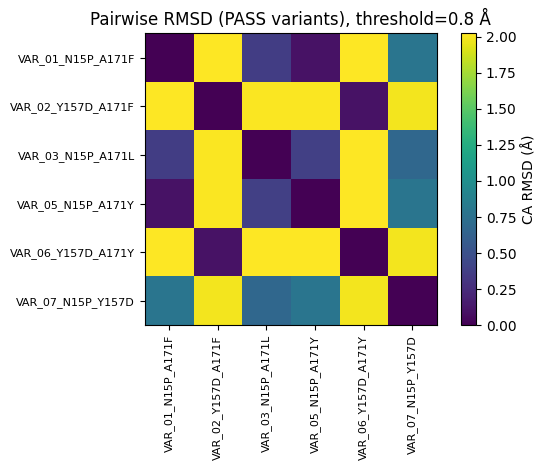

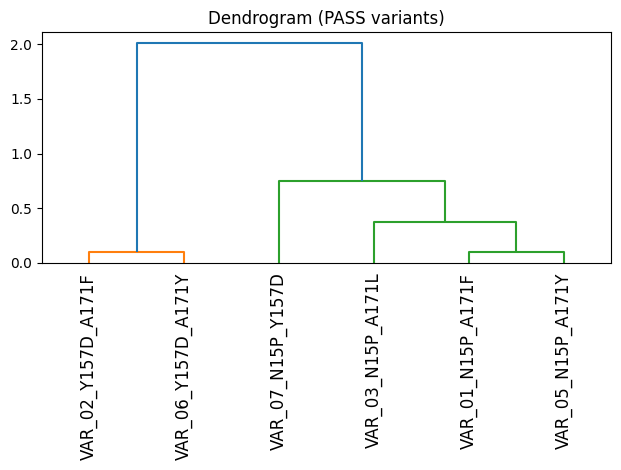

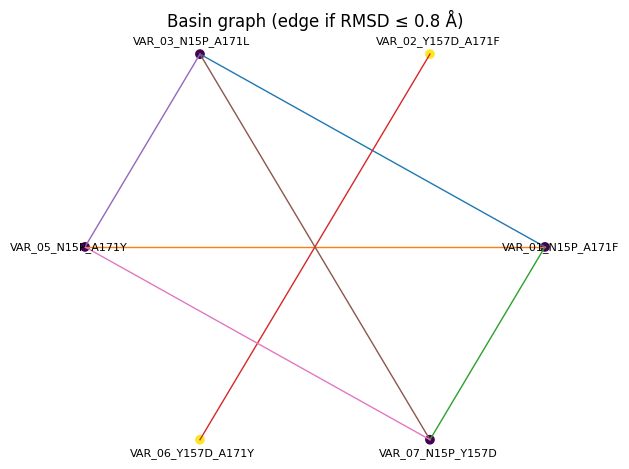

In [28]:
# -------------------------------------------------
# 28) Visualization of structural basins
# -------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =================================================
# Heatmap visualization
# =================================================

def plot_rmsd_heatmap(rmsd_df, threshold):
    plt.figure()
    plt.imshow(rmsd_df.values, interpolation="nearest")
    plt.xticks(
        range(len(rmsd_df.columns)),
        rmsd_df.columns,
        rotation=90,
        fontsize=8,
    )
    plt.yticks(
        range(len(rmsd_df.index)),
        rmsd_df.index,
        fontsize=8,
    )
    plt.colorbar(label="CA RMSD (Å)")
    plt.title(
        f"Pairwise RMSD (PASS variants), threshold={threshold} Å"
    )
    plt.tight_layout()
    plt.show()


# =================================================
# Dendrogram
# =================================================

def plot_rmsd_dendrogram(rmsd_df):
    try:
        from scipy.cluster.hierarchy import linkage, dendrogram
        from scipy.spatial.distance import squareform

        D = rmsd_df.values.copy()

        max_finite = (
            np.nanmax(D[np.isfinite(D)])
            if np.any(np.isfinite(D))
            else 10.0
        )
        D[~np.isfinite(D)] = max_finite * 2

        condensed = squareform(D, checks=False)
        Z = linkage(condensed, method="average")

        plt.figure()
        dendrogram(
            Z,
            labels=rmsd_df.index.tolist(),
            leaf_rotation=90,
        )
        plt.title("Dendrogram (PASS variants)")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(
            "[INFO] SciPy dendrogram unavailable "
            "(or failed). Heatmap above is still valid."
        )
        print("Reason:", repr(e))


# =================================================
# Basin graph
# =================================================

def plot_basin_graph(rmsd_df, basin_map, threshold):
    names = rmsd_df.index.tolist()
    m = len(names)

    angles = np.linspace(0, 2 * np.pi, m, endpoint=False)
    pos = {
        names[i]: (np.cos(angles[i]), np.sin(angles[i]))
        for i in range(m)
    }

    plt.figure()

    # Edges
    for i in range(m):
        for j in range(i + 1, m):
            r = rmsd_df.iloc[i, j]
            if np.isfinite(r) and r <= threshold:
                x1, y1 = pos[names[i]]
                x2, y2 = pos[names[j]]
                plt.plot([x1, x2], [y1, y2], linewidth=1)

    # Node colors
    basin_list = sorted(set(basin_map.values()))
    basin_to_idx = {b: k for k, b in enumerate(basin_list)}

    xs, ys, cs = [], [], []
    for n in names:
        x, y = pos[n]
        xs.append(x)
        ys.append(y)
        cs.append(basin_to_idx.get(basin_map[n], -1))

    plt.scatter(xs, ys, c=cs)

    for n in names:
        x, y = pos[n]
        plt.text(
            x * 1.07,
            y * 1.07,
            n,
            fontsize=8,
            ha="center",
            va="center",
        )

    plt.axis("off")
    plt.title(
        f"Basin graph (edge if RMSD ≤ {threshold} Å)"
    )
    plt.tight_layout()
    plt.show()


# =================================================
# Orchestration
# =================================================

def visualize_structural_basins(
    rmsd_df,
    threshold,
):
    """
    Visualize RMSD structure and basin connectivity.
    Basin IDs are reconstructed if not present in CSV.
    """
    plot_rmsd_heatmap(rmsd_df, threshold)
    plot_rmsd_dendrogram(rmsd_df)

    # Reconstruct basin map from RMSD
    basin_map = assign_basins_from_rmsd(
        rmsd_df,
        threshold=threshold,
    )

    plot_basin_graph(
        rmsd_df,
        basin_map,
        threshold,
    )


# =================================================
# Execute
# =================================================

visualize_structural_basins(
    rmsd_df=rmsd_df,
    threshold=NEAREST_RMSD_CUTOFF,
)

# Composite Scoring, Ranking and Figures

In [29]:
# -------------------------------------------------
# 29) Variant rescoring metrics (PATCHED)
# -------------------------------------------------

import numpy as np
import pandas as pd
from pathlib import Path


# =================================================
# Geometry helpers (local, minimal)
# =================================================

def extract_seq_and_coords(structure):
    """
    Extract sequence and CA coordinates from first chain.
    """
    chain = get_chain(structure)

    seq = []
    coords = []

    for res in chain:
        if res.id[0] != " " or "CA" not in res:
            continue
        aa = res.resname
        seq.append(aa)
        coords.append(res["CA"].coord)

    return seq, np.asarray(coords), chain


def radius_of_gyration(coords):
    c = coords.mean(axis=0)
    return float(np.sqrt(np.mean(np.sum((coords - c) ** 2, axis=1))))


def compute_contact_density(coords, cutoff=NEIGHBOR_CUTOFF):
    """
    Mean CA neighbor count within cutoff.
    """
    n = len(coords)
    counts = []

    for i in range(n):
        d2 = np.sum((coords - coords[i]) ** 2, axis=1)
        counts.append(int(np.sum(d2 < cutoff**2)) - 1)

    return float(np.mean(counts))


# =================================================
# Structural hydrophobic patch (RESTORED)
# =================================================

def compute_hydrophobic_patch_size(chain, distance_cutoff=8.0):
    """
    Largest connected component of surface-exposed hydrophobic residues
    using CA–CA distance graph.
    """
    hydros = []

    for res in chain:
        if (
            res.id[0] == " "
            and "CA" in res
            and res.resname in HYDROPHOBIC_3
            and is_surface_residue(res, chain)
        ):
            hydros.append(res)

    if not hydros:
        return 0

    coords = np.array([res["CA"].coord for res in hydros])
    n = len(coords)

    adj = [[] for _ in range(n)]
    for i in range(n):
        d2 = np.sum((coords - coords[i]) ** 2, axis=1)
        nbrs = np.where((d2 < distance_cutoff**2) & (d2 > 0))[0]
        adj[i].extend(nbrs.tolist())

    visited = [False] * n
    max_size = 0

    for i in range(n):
        if visited[i]:
            continue
        stack = [i]
        visited[i] = True
        size = 0

        while stack:
            u = stack.pop()
            size += 1
            for v in adj[u]:
                if not visited[v]:
                    visited[v] = True
                    stack.append(v)

        max_size = max(max_size, size)

    return max_size


# =================================================
# Per-structure metrics
# =================================================

def compute_variant_metrics(variant_id: str, pdb_path: Path) -> dict | None:
    structure = parser.get_structure(variant_id, str(pdb_path))
    seq3, coords, chain = extract_seq_and_coords(structure)

    if len(coords) < 10:
        return None

    # Surface exposure (existing logic)
    surface = analyze_structure_surface(chain)

    return {
        "variant_id": variant_id,
        "length": surface["n_residues"],
        "contact_density_mean": compute_contact_density(coords),
        "radius_of_gyration": radius_of_gyration(coords),
        "surface_residues_proxy": surface["n_surface_residues"],
        "exposed_hydrophobic_count": surface["n_exposed_hydrophobic"],
        "exposed_hydrophobic_frac": surface["fraction_exposed_hydrophobic_surface"],
        "hydrophobic_patch_largest_component": compute_hydrophobic_patch_size(chain),
        **compute_charge_properties("".join(
            ProtParam.IUPACData.protein_letters_3to1.get(r, "X") for r in seq3
        )),
    }


# =================================================
# Orchestration
# =================================================

def run_variant_rescoring_scenario() -> pd.DataFrame:
    struct_path = RESULTS_DIR / SCENARIO / "variant_structural_validation.csv"
    df_struct = pd.read_csv(struct_path)

    df_pass = df_struct[
        (df_struct["PASS"] == True) &
        (df_struct["variant_id"].str.startswith("VAR_"))
    ].copy()

    rows = []

    for _, r in df_pass.iterrows():
        m = compute_variant_metrics(
            r["variant_id"],
            Path(r["pdb_path"]),
        )
        if m is not None:
            m["target_rmsd"] = r["target_rmsd"]
            m["nearest_variant_rmsd"] = r["nearest_variant_rmsd"]
            rows.append(m)

    df = pd.DataFrame(rows)

    # Add TARGET
    target_row = df_struct[df_struct["variant_id"] == "TARGET"].iloc[0]
    target_metrics = compute_variant_metrics(
        "TARGET",
        Path(target_row["pdb_path"]),
    )
    target_metrics.update({
        "target_rmsd": 0.0,
        "nearest_variant_rmsd": np.nan,
    })

    df = pd.concat([pd.DataFrame([target_metrics]), df], ignore_index=True)

    out_csv = RESULTS_DIR / SCENARIO / "variant_rescoring_metrics.csv"
    df.to_csv(out_csv, index=False)

    return df.sort_values(
        [
            "hydrophobic_patch_largest_component",
            "exposed_hydrophobic_frac",
            "nearest_variant_rmsd",
        ],
        ascending=[True, True, True],
        na_position="first",
    ).reset_index(drop=True)


# =================================================
# Execute
# =================================================

df_rescoring = run_variant_rescoring_scenario()
display(df_rescoring)

,variant_id,length,contact_density_mean,radius_of_gyration,surface_residues_proxy,exposed_hydrophobic_count,exposed_hydrophobic_frac,hydrophobic_patch_largest_component,pI,charge_pH_6.8,charge_pH_7.4,charge_pH_8.0,target_rmsd,nearest_variant_rmsd
0,VAR_07_N15P_Y157D,272,18.933824,16.765360,77,17,0.221,3,5.53,-0.17,-0.44,-0.76,0.572806,0.676942
1,VAR_03_N15P_A171L,272,18.860294,16.765371,79,18,0.228,3,5.53,-0.17,-0.44,-0.76,0.638220,0.363979
2,TARGET,272,18.669118,16.816872,83,19,0.229,3,5.53,-0.17,-0.44,-0.76,0.000000,NaN
3,VAR_05_N15P_A171Y,272,18.845588,16.794907,79,19,0.241,3,5.53,-0.17,-0.44,-0.76,0.611666,0.097780
4,VAR_01_N15P_A171F,272,18.794118,16.803276,79,20,0.253,3,5.53,-0.17,-0.44,-0.76,0.613088,0.097780
5,VAR_02_Y157D_A171F,272,18.698529,16.805824,85,20,0.235,4,5.53,-0.17,-0.44,-0.76,2.067725,0.099895
6,VAR_06_Y157D_A171Y,272,18.683824,16.812618,84,20,0.238,4,5.53,-0.17,-0.44,-0.76,2.070385,0.099895


In [30]:
# -------------------------------------------------
# 30) Composite scoring + ranking
# -------------------------------------------------

import numpy as np
import pandas as pd
from pathlib import Path

# =================================================
# Utility: robust normalization
# =================================================

def robust_z(x):
    """
    Robust z-score using median and MAD.
    """
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0:
        return np.zeros_like(x, dtype=float)
    return (x - med) / (1.4826 * mad)


def normalize_01(x, invert=False):
    """
    Normalize array to [0,1].
    """
    x = np.asarray(x, dtype=float)
    lo, hi = np.nanpercentile(x, [5, 95])
    if hi == lo:
        y = np.zeros_like(x)
    else:
        y = np.clip((x - lo) / (hi - lo), 0, 1)
    return 1.0 - y if invert else y


# =================================================
# Composite scoring definition
# =================================================

def compute_composite_score(df):
    """
    Compute composite desirability score.
    Higher = better.
    """

    score = np.zeros(len(df), dtype=float)

    components = {}

    # ---- Structural consistency (lower better) ----
    components["nn_rmsd"] = normalize_01(
        df["nearest_variant_rmsd"], invert=True
    )

    # ---- Compactness / stability proxies ----
    components["contact_density"] = normalize_01(
        df["contact_density_mean"], invert=False
    )

    components["rg"] = normalize_01(
        df["radius_of_gyration"], invert=True
    )

    # ---- Surface hydrophobicity penalties ----
    components["hydro_frac"] = normalize_01(
        df["exposed_hydrophobic_frac"], invert=True
    )

    components["hydro_patch"] = normalize_01(
        df["hydrophobic_patch_largest_component"], invert=True
    )

    # ---- Electrostatics sanity (keep near WT-ish) ----
    if "net_charge_pH_7.4" in df.columns:
        z_charge = np.abs(robust_z(df["net_charge_pH_7.4"]))
        components["charge_dev"] = normalize_01(z_charge, invert=True)

    # ---- Weights (interpretable, editable) ----
    WEIGHTS = {
        "nn_rmsd": 0.30,
        "contact_density": 0.15,
        "rg": 0.10,
        "hydro_frac": 0.15,
        "hydro_patch": 0.20,
        "charge_dev": 0.10,
    }

    for k, w in WEIGHTS.items():
        if k in components:
            score += w * components[k]

    out = df.copy()
    out["composite_score"] = score

    # Optional: expose components for transparency
    for k, v in components.items():
        out[f"score_{k}"] = v

    return out


# =================================================
# Ranking helpers
# =================================================

def rank_variants(df):
    """
    Add global and per-basin rankings.
    """
    df = df.copy()

    df["global_rank"] = (
        df["composite_score"]
        .rank(ascending=False, method="dense")
        .astype(int)
    )

    if "basin_id" in df.columns:
        df["basin_rank"] = (
            df.groupby("basin_id")["composite_score"]
            .rank(ascending=False, method="dense")
            .astype("Int64")
        )

    return df


def select_top_per_basin(df, n=1):
    """
    Pick top-N variants per basin.
    """
    if "basin_id" not in df.columns:
        raise ValueError("No basin_id column available.")
    return (
        df.sort_values("composite_score", ascending=False)
          .groupby("basin_id")
          .head(n)
          .reset_index(drop=True)
    )


# =================================================
# Scenario-level orchestration
# =================================================

def run_composite_scoring():
    in_csv = RESULTS_DIR / SCENARIO / "variant_rescoring_metrics.csv"
    out_csv = RESULTS_DIR / SCENARIO / "variant_composite_ranking.csv"

    df = pd.read_csv(in_csv)

    # Exclude TARGET from ranking (keep for reference)
    df_target = df[df["variant_id"] == "TARGET"]
    df_var = df[df["variant_id"].str.startswith("VAR_")].copy()

    df_var = compute_composite_score(df_var)
    df_var = rank_variants(df_var)

    out = pd.concat([df_target, df_var], ignore_index=True)

    out_csv.parent.mkdir(exist_ok=True)
    out.to_csv(out_csv, index=False)

    return out.sort_values(
        ["composite_score"],
        ascending=False,
        na_position="last",
    ).reset_index(drop=True)


# =================================================
# Execute
# =================================================

df_ranked = run_composite_scoring()
display(df_ranked)

,variant_id,length,contact_density_mean,radius_of_gyration,surface_residues_proxy,exposed_hydrophobic_count,exposed_hydrophobic_frac,hydrophobic_patch_largest_component,pI,charge_pH_6.8,...,charge_pH_8.0,target_rmsd,nearest_variant_rmsd,composite_score,score_nn_rmsd,score_contact_density,score_rg,score_hydro_frac,score_hydro_patch,global_rank
0,VAR_05_N15P_A171Y,272,18.845588,16.794907,79,19,0.241,3,5.53,-0.17,...,-0.76,0.611666,0.097780,0.688723,1.000000,0.693548,0.351497,0.330275,1.0,1.0
1,VAR_03_N15P_A171L,272,18.860294,16.765371,79,18,0.228,3,5.53,-0.17,...,-0.76,0.638220,0.363979,0.675366,0.468582,0.758065,0.999812,0.807339,1.0,2.0
2,VAR_07_N15P_Y157D,272,18.933824,16.765360,77,17,0.221,3,5.53,-0.17,...,-0.76,0.572806,0.676942,0.600000,0.000000,1.000000,1.000000,1.000000,1.0,3.0
3,VAR_01_N15P_A171F,272,18.794118,16.803276,79,20,0.253,3,5.53,-0.17,...,-0.76,0.613088,0.097780,0.586940,1.000000,0.467742,0.167783,0.000000,1.0,4.0
4,VAR_02_Y157D_A171F,272,18.698529,16.805824,85,20,0.235,4,5.53,-0.17,...,-0.76,2.067725,0.099895,0.399745,0.995776,0.048387,0.111848,0.550459,0.0,5.0
5,VAR_06_Y157D_A171Y,272,18.683824,16.812618,84,20,0.238,4,5.53,-0.17,...,-0.76,2.070385,0.099895,0.364788,0.995776,0.000000,0.000000,0.440367,0.0,6.0
6,TARGET,272,18.669118,16.816872,83,19,0.229,3,5.53,-0.17,...,-0.76,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Pareto-optimal variants: 3 / 6


,variant_id,target_rmsd,exposed_hydrophobic_frac,composite_score
3,VAR_05_N15P_A171Y,0.611666,0.241,0.688723
2,VAR_03_N15P_A171L,0.638220,0.228,0.675366
5,VAR_07_N15P_Y157D,0.572806,0.221,0.600000


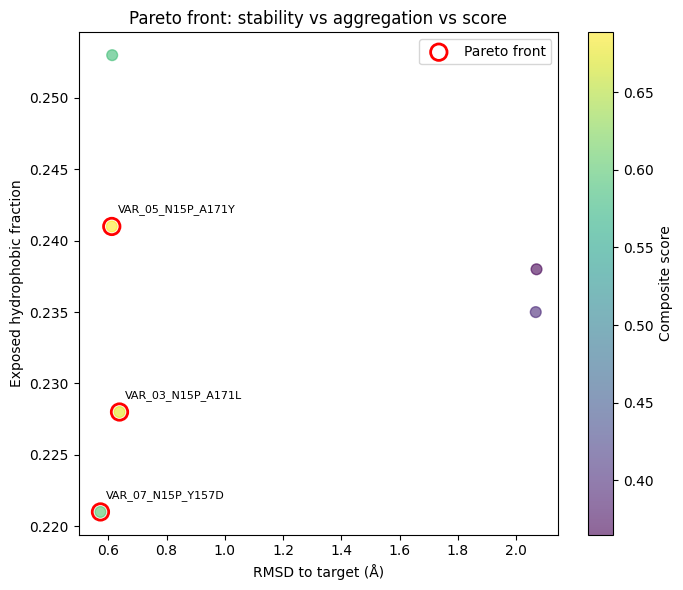

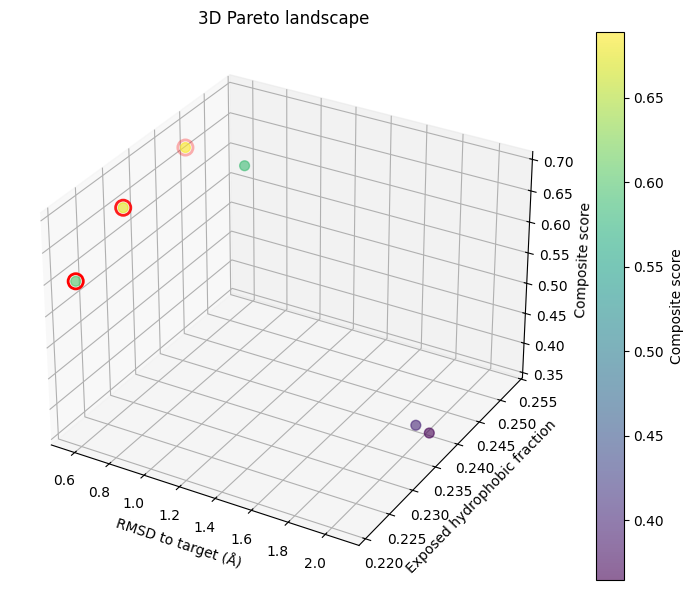

In [31]:
# -------------------------------------------------
# 31) Pareto front visualization
# RMSD vs hydrophobicity vs composite score
# -------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Load composite-scored table
# -----------------------------
CSV = RESULTS_DIR / SCENARIO / "variant_composite_ranking.csv"
df = pd.read_csv(CSV)

# Keep variants only (exclude TARGET)
df = df[df["variant_id"].str.startswith("VAR_")].copy()

# Required columns
required = [
    "variant_id",
    "target_rmsd",
    "exposed_hydrophobic_frac",
    "composite_score",
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Drop NaNs
df = df.dropna(subset=required).reset_index(drop=True)

# -------------------------------------------------
# Pareto dominance test
# -------------------------------------------------
def is_dominated(i, data):
    """
    Point i is dominated if another point is:
      <= in RMSD
      <= in hydrophobic exposure
      >= in composite score
    with at least one strict improvement.
    """
    xi = data.loc[i]
    for j in range(len(data)):
        if i == j:
            continue
        xj = data.loc[j]
        if (
            (xj["target_rmsd"] <= xi["target_rmsd"]) and
            (xj["exposed_hydrophobic_frac"] <= xi["exposed_hydrophobic_frac"]) and
            (xj["composite_score"] >= xi["composite_score"]) and
            (
                (xj["target_rmsd"] < xi["target_rmsd"]) or
                (xj["exposed_hydrophobic_frac"] < xi["exposed_hydrophobic_frac"]) or
                (xj["composite_score"] > xi["composite_score"])
            )
        ):
            return True
    return False


df["pareto"] = [
    not is_dominated(i, df) for i in range(len(df))
]

df_pareto = df[df["pareto"]].copy()

print(f"Pareto-optimal variants: {len(df_pareto)} / {len(df)}")
display(
    df_pareto.sort_values("composite_score", ascending=False)[
        ["variant_id", "target_rmsd", "exposed_hydrophobic_frac", "composite_score"]
    ]
)

# -------------------------------------------------
# 2D Pareto plot
# -------------------------------------------------
plt.figure(figsize=(7, 6))

sc = plt.scatter(
    df["target_rmsd"],
    df["exposed_hydrophobic_frac"],
    c=df["composite_score"],
    cmap="viridis",
    s=60,
    alpha=0.6,
)

plt.scatter(
    df_pareto["target_rmsd"],
    df_pareto["exposed_hydrophobic_frac"],
    edgecolors="red",
    facecolors="none",
    s=140,
    linewidths=2,
    label="Pareto front",
)

for _, r in df_pareto.iterrows():
    plt.text(
        r["target_rmsd"] + 0.02,
        r["exposed_hydrophobic_frac"] + 0.001,
        r["variant_id"],
        fontsize=8,
    )

plt.xlabel("RMSD to target (Å)")
plt.ylabel("Exposed hydrophobic fraction")
plt.title("Pareto front: stability vs aggregation vs score")
plt.colorbar(sc, label="Composite score")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 3D Pareto scatter
# -------------------------------------------------
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

p = ax.scatter(
    df["target_rmsd"],
    df["exposed_hydrophobic_frac"],
    df["composite_score"],
    c=df["composite_score"],
    cmap="viridis",
    s=50,
    alpha=0.6,
)

ax.scatter(
    df_pareto["target_rmsd"],
    df_pareto["exposed_hydrophobic_frac"],
    df_pareto["composite_score"],
    edgecolors="red",
    facecolors="none",
    s=120,
    linewidths=2,
)

ax.set_xlabel("RMSD to target (Å)")
ax.set_ylabel("Exposed hydrophobic fraction")
ax.set_zlabel("Composite score")
ax.set_title("3D Pareto landscape")

fig.colorbar(p, label="Composite score")
plt.tight_layout()
plt.show()